# Emotion Classification in Ambiguous Text: Complete Analysis

**Thesis:** *A Study of Large Language Models' Emotion Classification in Ambiguous Text with Perceived Authorship*

This notebook is the single, complete analysis: it establishes the ambiguity-typing methodology and
the resulting 300-text balanced sample (Part 1), then runs the full RQ1/RQ2/RQ3, H1-H4 model
experiment analysis on that sample (Part 2). Structure follows question -> code -> answer throughout.

**Ambiguity typing** (Part 1): every text in the 1,200-text corpus is typed Unambiguous /
Author-Independent Ambiguous / Author-Relevant Ambiguous by an LLM judge that reads it under two
distinct personas -- if the judged emotion differs between them (a "flip"), the text is
Author-Relevant Ambiguous outright, regardless of neutral-reader agreement. Only non-flipped texts
are split into Unambiguous vs. Author-Independent by an agreement threshold (see
`scripts/classify_ambiguity_pools.py` for the exact rule). This is compared against the earlier,
purely agreement-based manual typing, and used to draw the 300-text balanced sample (100 per pool)
that the rest of the notebook analyzes.

**Model experiment** (Part 2):
- **4 framing conditions**: neutral / generic_human / persona_a / persona_b -- this directly
  answers proposal Section 5's "does 'politician' vs 'comedian' change the perceived emotion" key
  contrast, tested explicitly in the persona_a-vs-persona_b section below.
- **7 models**: 3 hosted API models -- OpenAI (gpt-5-nano), Claude (haiku-4-5), Gemini
  (3.6-flash) -- plus 4 local open-source models run via Ollama: Qwen3 (8b), Gemma3 (4b),
  Ministral (3:8b), Llama 3.1 (8b).

Data: 300 texts (100/pool) x 4 framings x 3 prompt variants x 2 label formats x 7 models = 50,400
classifications (`experiment_results_all.csv`, unified from the three pool-specific files the data
collection pipeline produced), 0 unresolved errors.

**Label normalization** (`normalize_labels.py`): the local models frequently answered with
mechanical formatting the raw-string comparison doesn't recognize -- markdown bold (`**joy**`,
mostly Ministral), or the numbered-list's digit/prefix instead of the word (`8`, `7. relief`,
mostly Qwen3 and Llama 3.1). All of these local-model-heavy patterns are cleaned into
`<Model>_label_norm` columns (raw columns untouched) before any comparison in this notebook. This
is a mechanical fix, not a correctness bump: genuinely off-list answers (invented emotions,
refusals, non-English text) are NOT force-mapped and still count as wrong. The effect was large --
e.g. Llama 3.1's unambiguous-set accuracy went from 12% (raw string match) to 95% (normalized).

RQ1 and RQ3/H4 draw on the Phase 4 human annotation study: persona_a/persona_b rated by
independent raters per (text, side) pair (minimum 3, up to 7), neutral condition reused from the
original corpus annotation where label-set-compatible, distributed across individually-assigned
Google Forms (60 forms covering the original 300-text sample, plus a 6-form extension covering the
29 texts swapped in by the pool-classification methodology). Data collection is complete: all 600
(text_id, side) pairs have 3 or more raters (`human_annotations.csv`).

## 0. Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.metrics import f1_score
from statsmodels.stats.contingency_tables import cochrans_q
from scipy.stats import chi2
import itertools

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.max_colwidth', 140)

PARENT = Path.home() / 'Desktop' / 'thesis'
BASE = PARENT / 'thesis final'

PALETTE = {
    'Unambiguous':                  '#4C72B0',
    'Author-Independent Ambiguous': '#DD8452',
    'Author-Relevant Ambiguous':    '#55A868',
}
LABEL_ORDER = ['Unambiguous', 'Author-Independent Ambiguous', 'Author-Relevant Ambiguous']

# _norm columns (see normalize_labels.py) fix mechanical formatting artifacts in the raw model
# output -- markdown bold wrapping, numbered-list digits/prefixes instead of the label word, and
# casing -- before comparison. This matters most for the local models: Ministral wrapped ~80% of
# its answers in markdown bold ('**joy**'), and Qwen3/Llama 3.1 often answered with just the
# numbered list's digit ('8') instead of the word. Genuinely off-list answers (invented emotions,
# refusals, non-English text) are NOT force-mapped to a label by normalization -- they still
# correctly fail to match gold, same as before.
MODEL_COLS = {
    'OpenAI': 'ChatGPT_label_norm', 'Claude': 'Claude_label_norm', 'Gemini': 'Gemini_label_norm',
    'Qwen3': 'Qwen3_label_norm', 'Gemma3': 'Gemma3_label_norm', 'Ministral': 'Ministral_label_norm',
    'Llama31': 'Llama31_label_norm',
}
AMBIG_TYPES = ['unambiguous', 'author_independent', 'author_relevant']
AMBIG_LABELS = {'unambiguous': 'Unambiguous', 'author_independent': 'Author-Independent', 'author_relevant': 'Author-Relevant'}
FRAMINGS = ['neutral', 'generic_human', 'persona_a', 'persona_b']
colors = {
    'OpenAI': '#4C6EF5', 'Claude': '#F76707', 'Gemini': '#12B886',
    'Qwen3': '#AE3EC9', 'Gemma3': '#E64980', 'Ministral': '#F59F00', 'Llama31': '#495057',
}

# experiment_results_all.csv unifies the three pool-specific files the data collection pipeline
# wrote (kept separate during collection so run_classification.py could track per-pool progress
# independently -- see scripts/build_unified_dataset.py). 'classification' already carries the pool
# label, so dfs below just filters the one unified file back into per-pool slices for the
# analysis cells below.
all_results = pd.read_csv(BASE / 'experiment_results_all.csv')
POOL_TO_KEY = {
    'Unambiguous': 'unambiguous',
    'Author-Independent Ambiguous': 'author_independent',
    'Author-Relevant Ambiguous': 'author_relevant',
}
dfs = {key: all_results[all_results['classification'] == label].reset_index(drop=True)
       for label, key in POOL_TO_KEY.items()}

def baseline_slice(df):
    return df[(df.framing_condition == 'neutral') & (df.prompt_variant == 'zero_shot') & (df.label_format == 'numbered')]

def shift_flags(df, col):
    """1 if the model's label differs across ANY of the 4 framing conditions for that text."""
    flags = []
    for tid, g in df.groupby('text_id'):
        if len(g) == 4:
            flags.append(int(len(set(g[col].astype(str).str.strip().str.lower())) > 1))
    return flags

def cochrans_q_matrix(df, col):
    """4-column binary matrix: does generic_human / persona_a / persona_b match neutral for this text?
    (first column is a constant 1 -- neutral vs itself -- included so all 4 conditions line up in one matrix.)"""
    rows = []
    for tid, g in df.groupby('text_id'):
        g = g.set_index('framing_condition')
        if len(g) != 4:
            continue
        neutral = str(g.loc['neutral', col]).strip().lower()
        gh = str(g.loc['generic_human', col]).strip().lower()
        pa = str(g.loc['persona_a', col]).strip().lower()
        pb = str(g.loc['persona_b', col]).strip().lower()
        rows.append([1, int(gh == neutral), int(pa == neutral), int(pb == neutral)])
    return np.array(rows)

def cochran_armitage(counts_shifted, counts_total, scores=(0, 1, 2)):
    N = sum(counts_total)
    p_bar = sum(counts_shifted) / N
    num = sum(s * (c - t * p_bar) for s, c, t in zip(scores, counts_shifted, counts_total))
    denom_var = p_bar * (1 - p_bar) * (sum(t * s**2 for s, t in zip(scores, counts_total)) -
                                        (sum(t * s for s, t in zip(scores, counts_total)))**2 / N)
    z = num / np.sqrt(denom_var)
    p = 2 * (1 - chi2.cdf(z**2, df=1))
    return z, p

# Part 1: Ambiguity Typing Methodology

## 1. Load manual and flip-first classifications

In [2]:
orig = pd.read_csv(PARENT / 'annotated_reader_summary.csv')
orig = orig.rename(columns={'classfication': 'classification'})
orig = orig[['text_id', 'classification']].rename(columns={'classification': 'original_classification'})

fixed = pd.read_csv(BASE / 'ambiguity_classification_1200.csv')
print(f'Final classification rows: {len(fixed)}')
print(f'Columns: {list(fixed.columns)}')

df = fixed.merge(orig, on='text_id', how='left')
assert df['original_classification'].notna().all(), 'every text should have an original label'
print(f'\nMerged: {len(df)} texts with both manual and final classification')

Final classification rows: 1200
Columns: ['text_id', 'batch', 'persona_a', 'persona_b', 'rationale', 'judge_a', 'judge_b', 'text', 'author_emotion', 'reader_majority', 'majority_share', 'author_matches_readers', 'flip', 'new_classification']

Merged: 1200 texts with both manual and final classification


## 2. Representative examples (final classification)

In [3]:
for label in LABEL_ORDER:
    sample = df[df['new_classification'] == label].sample(5, random_state=42)
    print(f'\n{"="*90}')
    print(f'  {label.upper()}')
    print(f'{"="*90}')
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        flip_mark = 'FLIP' if row['flip'] else 'no flip'
        print(f'\n{i}. [author={row.author_emotion}  readers={row.reader_majority} '
              f'({int(row.majority_share*100)}% agree)  judge_a={row.judge_a}  judge_b={row.judge_b}  ({flip_mark})]')
        print(f'   text: {row.text[:200]}')
        print(f'   persona_a: {row.persona_a}')
        print(f'   persona_b: {row.persona_b}')
        print(f'   rationale: {row.rationale}')


  UNAMBIGUOUS

1. [author=joy  readers=joy (100% agree)  judge_a=joy  judge_b=pride  (FLIP)]
   text: I felt ... when I became partners with my partner
   persona_a: two romantic partners who formalized their relationship after years together
   persona_b: two co-founders who formalized a business partnership
   rationale: Becoming partners reads as personal joy in a romantic context, and as professional pride in a business context.

2. [author=anger  readers=anger (100% agree)  judge_a=fear  judge_b=no-emotion  (FLIP)]
   text: I felt ... because my college professors were being unresponsive to important emails regarding a certain assignment, The professor said that they would be available to answer questions within the time
   persona_a: a scholarship student whose GPA is riding on this one assignment
   persona_b: a student generally used to disorganized administration who expects little
   rationale: A scholarship student whose GPA depends on the assignment feels real fear about t

## 3. Balanced sample (100 per pool)

The 300-text balanced sample used throughout the experiment is produced by
`scripts/classify_ambiguity_pools.py`, which applies the flip-first classification rule (see the
notebook intro above) after dropping texts whose author_emotion or reader_majority is 'boredom' or
'no-emotion' (outside the 11-label set), then samples 100 texts per pool, excluding the three
reserved few-shot/one-shot example texts (468, 393, 417). Keeping that logic in one place (rather
than duplicated here) means there is exactly one way the sample gets generated, and it can be
re-run (`python scripts/classify_ambiguity_pools.py`) to regenerate `sampled_texts.csv` and the
three per-pool `experiment_results_*.csv` files from scratch, reproducibly.

This section just loads and previews the result.

In [4]:
sampled = pd.read_csv(BASE / 'sampled_texts.csv')

print(sampled['classification'].value_counts().reindex(LABEL_ORDER).to_string())
print(f'\nTotal: {len(sampled)} texts, {sampled.text_id.nunique()} unique')

sampled[['text_id', 'classification', 'author_emotion', 'reader_majority', 'text']].head(10)

classification
Unambiguous                     100
Author-Independent Ambiguous    100
Author-Relevant Ambiguous       100

Total: 300 texts, 300 unique


,text_id,classification,author_emotion,reader_majority,text
0,3118,Unambiguous,anger,anger,A man was walking late at night with his dog off a leash. It ran into my garden and killed my sleeping cat. He walked away without sayin...
1,315,Unambiguous,anger,anger,I felt ... the other day because our fire alarm in the building went off as Tropical Storm Ida came through - we had to stand outside in...
2,340,Unambiguous,anger,anger,A next door neighbour has once again started running generators and power tools.
3,437,Unambiguous,anger,anger,.. when a person I served at work ignored what I asked causing me to make a computer error
4,458,Unambiguous,anger,anger,"An older man was in the wrong lane at a round about. He nearly hit me, I had to slam on and his answer was well move then I didn’t hit y..."
5,4146,Unambiguous,anger,anger,I felt ... when I was at uni and someone stole my fishcake from the freezer. Had nothing to eat in the evening that day.
6,4150,Unambiguous,anger,anger,My mother invited my unvaccinated sister and her son over to play with my kids without my knowledge.
7,481,Unambiguous,anger,anger,i was in a restaurant and they forgot my order but they blamed me for it. i was still charged for the meal even though i never received it.
8,5166,Unambiguous,anger,anger,my permanent work contract was not offered to me at the end of my 6 month term even though it was promised it would be
9,612,Unambiguous,anger,anger,I witnessed a resident being emotionally abused by a carer in the care home where I worked.


# Part 2: Model Experiment Analysis (RQ1-RQ3, H1-H4)

## Q0. What does the sampled data actually look like?

In [5]:
base = {}
for name, df in dfs.items():
    b = df.drop_duplicates('text_id')[['text_id','text','author_emotion','reader_majority']].copy()
    b['word_count'] = b['text'].astype(str).str.split().str.len()
    b['author_matches_readers'] = (b['author_emotion'].astype(str).str.strip().str.lower()
                                    == b['reader_majority'].astype(str).str.strip().str.lower())
    base[name] = b

for name, b in base.items():
    print(f"--- {AMBIG_LABELS[name]} (n={len(b)}) ---")
    print(f"  mean word count: {b['word_count'].mean():.1f}  (min={b['word_count'].min()}, max={b['word_count'].max()})")
    print(f"  author-reader label match rate: {b['author_matches_readers'].mean():.1%}")
    print()

--- Unambiguous (n=100) ---
  mean word count: 24.6  (min=4, max=180)
  author-reader label match rate: 100.0%

--- Author-Independent (n=100) ---
  mean word count: 23.6  (min=3, max=203)
  author-reader label match rate: 41.0%

--- Author-Relevant (n=100) ---
  mean word count: 19.8  (min=2, max=186)
  author-reader label match rate: 31.0%



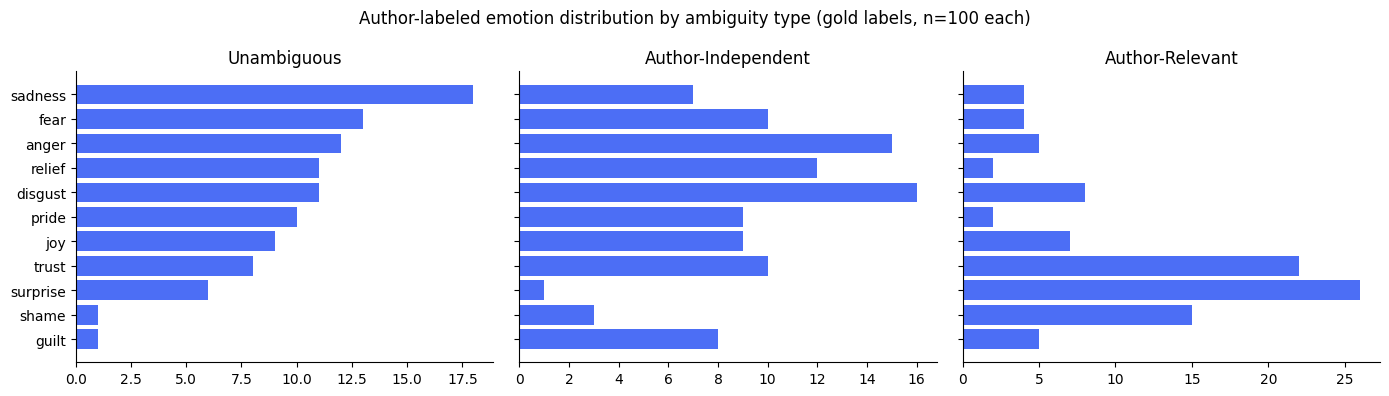

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, name in zip(axes, AMBIG_TYPES):
    counts = base[name]['author_emotion'].value_counts()
    ax.barh(counts.index, counts.values, color='#4C6EF5')
    ax.set_title(AMBIG_LABELS[name])
    ax.invert_yaxis()
fig.suptitle('Author-labeled emotion distribution by ambiguity type (gold labels, n=100 each)')
plt.tight_layout()
plt.show()

**Answer:** this sample is drawn from the final flip-first ambiguity classification -- see
*Part 1: Ambiguity Typing Methodology* above for the full comparison against the earlier manual
typing (54.4% of the 1,200 corpus texts land in a different pool between the two approaches).
Check the author-reader match rate above against that section's numbers as a sanity check that
the sample matches.

## Inter-Annotator Agreement (Phase 4 rater pool)

**Supervisor's ask:** how reliable is the annotator pool as a whole? Computed via
`scripts/compute_iaa.py`, which joins the same `form_assignment*.json` + `raw_responses*.csv`
sources `build_human_annotations.py` uses, but keeps every individual rater's label (instead of
collapsing to a majority vote) so Fleiss' kappa can be computed per (text_id, side). Restricted to
the 422 of 600 (text_id, side) pairs with exactly 3 raters (Fleiss' kappa needs equal n per item;
a handful of pairs have 4-7 raters from overlapping form assignments and are excluded from the
kappa computation, though not from the majority-vote data used elsewhere in this notebook).


,pool,side,fleiss_kappa,raw_agreement,n_items
0,unambiguous,a,0.377162,0.281690,71
1,unambiguous,b,0.521179,0.430769,65
2,author_independent,a,0.253006,0.169231,65
3,author_independent,b,0.287715,0.197368,76
4,author_relevant,a,0.206753,0.138889,72
5,author_relevant,b,0.244248,0.178082,73


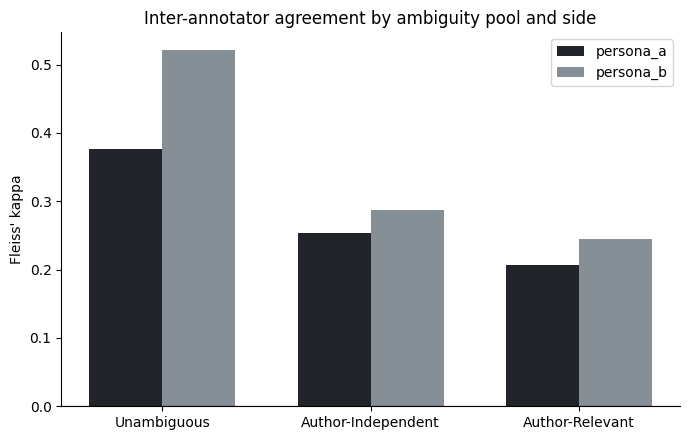

In [7]:
iaa = pd.read_csv(BASE / "iaa_results.csv")
display(iaa)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
width = 0.35
pools = ["unambiguous", "author_independent", "author_relevant"]
for i, side in enumerate(["a", "b"]):
    vals = [iaa[(iaa.pool == p) & (iaa.side == side)]["fleiss_kappa"].values[0] for p in pools]
    ax.bar(x + i * width, vals, width, label=f"persona_{side}", color="#212529" if side == "a" else "#868e96")
ax.set_xticks(x + width / 2)
ax.set_xticklabels([AMBIG_LABELS[p] for p in pools])
ax.set_ylabel("Fleiss' kappa")
ax.set_title("Inter-annotator agreement by ambiguity pool and side")
ax.legend()
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


**Answer:** overall Fleiss' kappa across all 422 three-rater items is **0.325** (raw 3/3
agreement 23.0%) -- "fair" agreement by the conventional Landis & Koch bands (0.21-0.40), which is
in line with what's typical for free-choice emotion annotation over a fine-grained 13-label set
(much lower ceiling than binary or few-category tasks). Agreement is not uniform: **Unambiguous
(kappa 0.447) > Author-Independent (0.272) > Author-Relevant (0.232)**, and this ordering holds for
both persona_a and persona_b considered separately. This is a useful independent check on the
ambiguity-pool typing itself -- texts typed as harder-to-agree-on by the flip-first LLM-judge rule
are, independently, exactly the texts where real human raters agree with each other less. Side a
and side b are close (kappa 0.286 vs 0.361 overall) with no consistent direction across pools, so
there's no evidence one persona wording is systematically easier or harder for raters to agree on
than the other.


## RQ1. Does perceived author identity significantly influence HUMAN emotion judgments of ambiguous texts? (H1)

**Status: complete, using the 2026-09-17 redo + a 2026-09-19 aggregation fix.** Phase 4 design:
persona_a/persona_b judgments come from 60 individually-assigned Google Forms covering the
original 300-text sample, a 6-form Batch 2 extension covering 29 rebalanced replacement texts,
and a 21-form redo (`persona_redo_20260917/`) that re-collected ratings for 102 texts whose
original persona ratings were stale or missing after the hidden-emotion-leak text fix (3+ raters
per text-persona pair throughout). See `persona_redo_20260917/README.md` for the full
build/merge history.

**Two distinct neutral baselines, kept separate throughout this section (never call either just
"neutral" -- they disagree with each other often enough that conflating them is misleading):**
- **`gathered_neutral`**: this study's own neutral-condition rating, collected directly on
  2026-09-17 (10 Google Forms) and topped up 2026-09-20 once more responses came in -- each
  form's first 3 responses by timestamp are kept (matching persona's 3-rater redundancy), later
  ones dropped. The correct rater pool and exact task, now 3 raters/text like everything else.
- **`corpus_neutral`**: Phase 2's `reader_majority`, reused from the original corpus -- a
  disjoint rater pool that never saw this study's framing task, but a 5-rater majority per text.

- **H1** (this RQ): compares each ambiguity pool's neutral-condition human rating (bare text, no
  author framing) against the persona_a and persona_b judgments, mirroring the LLM shift-rate
  analysis in RQ2 below but for humans. Reported for **both** neutral baselines.
- **H4** (RQ3, partial proxy): the comparison below is neutral-vs-persona, not
  persona_a-vs-persona_b -- that isolates "does adding an author description move the judgment at
  all" from "do these two specific personas differ from each other" (answered separately as a
  noise-floor check, since persona_a and persona_b aren't hypothesized to differ systematically).
- **2026-09-19 fix -- majority-vote tie-breaking:** `build_human_annotations.py` and
  `01_build_redo_annotations.py` computed `human_majority` via `Counter.most_common(1)[0]`,
  which silently breaks a genuine tie (e.g. 3 raters giving 3 *different* emotions -- no real
  majority) by picking whichever answer happened to be first in the list, rather than flagging
  "no consensus." This affected **197 of 600 (33%) persona a/b (text, side) pairs**. Rebuilt via
  `persona_redo_20260917/scripts/05_rebuild_with_fixed_ties.py`, which leaves `human_majority`
  blank for a tie instead of guessing; the notebook drops those blanks before any human analysis
  (cell above). Cost: only **267 of 300 texts** (403 of 600 persona pairs) retain a genuine
  majority; persona_a-vs-persona_b specifically needs a real majority on *both* sides, so it runs
  on 43-47 texts/pool. Pre-fix backups: `*.bak_pre_tiefix*`.
- **2026-09-20 update -- gathered_neutral to 3 raters:** the same tie-safe majority rule applied
  to the new 3-rater `gathered_neutral` data too (previously trivial at 1 rater/text, where
  "majority" was always just that one answer). 54 of 300 texts (18%) now show a genuine 3-way
  tie even in the neutral condition -- 12% Unambiguous, 18% Author-Independent, 24%
  Author-Relevant, scaling with ambiguity exactly as the pool design predicts. Backups:
  `human_annotations.csv.bak_pre_3rater_neutral`,
  `complete_analysis.ipynb.bak_pre_3rater_neutral`.


In [8]:
human = pd.read_csv(BASE / 'human_annotations.csv')

# 2026-09-19 fix: build_human_annotations.py / 01_build_redo_annotations.py used to break a
# 3-way rater tie (e.g. one vote each for disgust/fear/anger) by picking whichever answer
# happened to be first in Counter.most_common()'s insertion-order tie-break -- silently turning
# "no consensus" into a fake majority. Both scripts (and human_annotations.csv) were rebuilt via
# persona_redo_20260917/scripts/05_rebuild_with_fixed_ties.py to leave human_majority blank for a
# genuine tie instead. Drop those here rather than let pandas turn the blank into the string
# 'nan' via the astype(str) below.
n_before_tie_drop = len(human)
human = human[human['human_majority'].notna()].reset_index(drop=True)
n_dropped_ties = n_before_tie_drop - len(human)

human['human_majority'] = human['human_majority'].astype(str).str.strip().str.lower()

# neutral rows (added in the 2026-09-17 redo, see persona_redo_20260917/README.md) carry the
# Title-Case pool label used in sampled_texts.csv; persona a/b rows carry the lowercase
# snake_case key used elsewhere in this notebook (AMBIG_TYPES) -- collapse both onto the
# snake_case key so pool filtering below works uniformly.
human['pool'] = human['pool'].replace(POOL_TO_KEY)

n_collected = len(human)

# Two distinct "neutral" baselines, kept separate throughout this section:
#  - gathered_neutral: the real neutral-condition rating this study collected directly
#    (10 Google Forms; each form got 4-7 responses by 2026-09-20, first 3 by timestamp kept
#    per form to match persona's redundancy) -- the correct rater pool, now 3 raters/text.
#  - corpus_neutral: Phase 2's reader_majority, reused from the original corpus (a disjoint
#    rater pool that never saw the persona-framing task, but a 5-rater majority per text).
gathered_neutral_by_text = human[human['side'] == 'neutral'].set_index('text_id')['human_majority'].to_dict()

corpus_neutral_by_text = {}
for name in AMBIG_TYPES:
    b = dfs[name].drop_duplicates('text_id')[['text_id', 'reader_majority']]
    for _, r in b.iterrows():
        corpus_neutral_by_text[r['text_id']] = str(r['reader_majority']).strip().lower()

human = human[(human['side'].isin(['a', 'b'])) & (human['n_raters'] >= 3)].reset_index(drop=True)
human['gathered_neutral'] = human['text_id'].map(gathered_neutral_by_text)
human['corpus_neutral'] = human['text_id'].map(corpus_neutral_by_text)

print(f"Human annotations: {n_collected + n_dropped_ties} (text_id, side) pairs collected across persona_a/persona_b/gathered_neutral "
      f"({n_dropped_ties} persona pairs dropped -- a genuine 3-way-or-worse rater tie with no true majority); "
      f"restricting persona_a/persona_b to the {len(human)} pairs with all 3+ assigned raters completed "
      f"(n_raters >= 3) AND a real majority, covering {human['text_id'].nunique()} unique texts, "
      f"{human['n_raters'].sum()} persona ratings. gathered_neutral: {human['gathered_neutral'].notna().sum()} "
      f"of those rows have a real gathered-neutral rating (3 raters/text, first 3 by timestamp). "
      f"corpus_neutral: "
      f"{human['corpus_neutral'].notna().sum()} have a reader_majority baseline (5 raters/text, different pool).")
human.groupby('pool')['n_raters'].agg(['count', 'mean', 'min', 'max']).rename(index=AMBIG_LABELS)


Human annotations: 900 (text_id, side) pairs collected across persona_a/persona_b/gathered_neutral (251 persona pairs dropped -- a genuine 3-way-or-worse rater tie with no true majority); restricting persona_a/persona_b to the 403 pairs with all 3+ assigned raters completed (n_raters >= 3) AND a real majority, covering 267 unique texts, 1369 persona ratings. gathered_neutral: 338 of those rows have a real gathered-neutral rating (3 raters/text, first 3 by timestamp). corpus_neutral: 403 have a reader_majority baseline (5 raters/text, different pool).


,count,mean,min,max
pool,,,,
Author-Independent,136,3.441176,3,7
Author-Relevant,137,3.445255,3,7
Unambiguous,130,3.300000,3,6


In [9]:
def human_shift_table():
    rows = []
    for name in AMBIG_TYPES:
        sub = human[human.pool == name]
        wide = sub.pivot(index='text_id', columns='side', values='human_majority')
        wide['gathered_neutral'] = sub.drop_duplicates('text_id').set_index('text_id')['gathered_neutral']
        wide['corpus_neutral'] = sub.drop_duplicates('text_id').set_index('text_id')['corpus_neutral']

        def rate(c1, c2):
            pair = wide[[c1, c2]].dropna()
            if len(pair) == 0:
                return np.nan, 0
            return (pair[c1] != pair[c2]).mean(), len(pair)

        for label, (c1, c2) in [('gathered_neutral vs corpus_neutral', ('gathered_neutral', 'corpus_neutral')),
                                 ('gathered_neutral vs persona_a', ('gathered_neutral', 'a')),
                                 ('gathered_neutral vs persona_b', ('gathered_neutral', 'b')),
                                 ('corpus_neutral vs persona_a', ('corpus_neutral', 'a')),
                                 ('corpus_neutral vs persona_b', ('corpus_neutral', 'b')),
                                 ('persona_a vs persona_b', ('a', 'b'))]:
            d, n = rate(c1, c2)
            rows.append({'ambiguity_type': AMBIG_LABELS[name], 'comparison': label, 'shift_rate': d, 'n_texts': n})
    return pd.DataFrame(rows)

human_shift = human_shift_table()
human_shift_pivot = human_shift.pivot(index='comparison', columns='ambiguity_type', values='shift_rate')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
human_n_pivot = human_shift.pivot(index='comparison', columns='ambiguity_type', values='n_texts')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]

print("Human judgment shift rate (row comparison), % of texts where the majority label differs -- "
      "persona_a/persona_b: 3+ raters/pair, real majority only (post tie-fix); gathered_neutral: this "
      "study's own neutral-condition rating (3 raters/text, first 3 responses per form kept 2026-09-20); corpus_neutral: Phase 2's "
      "reader_majority (5 raters/text, a different rater pool that never saw this task); "
      "gathered_neutral vs corpus_neutral: how much the two neutral baselines themselves disagree "
      "with each other, same texts:")
display((human_shift_pivot * 100).round(1))
print("\nN texts contributing to each cell (both sides of the comparison had a majority label available):")
display(human_n_pivot)


Human judgment shift rate (row comparison), % of texts where the majority label differs -- persona_a/persona_b: 3+ raters/pair, real majority only (post tie-fix); gathered_neutral: this study's own neutral-condition rating (3 raters/text, first 3 responses per form kept 2026-09-20); corpus_neutral: Phase 2's reader_majority (5 raters/text, a different rater pool that never saw this task); gathered_neutral vs corpus_neutral: how much the two neutral baselines themselves disagree with each other, same texts:


ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
comparison,,,
corpus_neutral vs persona_a,14.5,42.6,50.7
corpus_neutral vs persona_b,22.1,39.7,57.1
gathered_neutral vs corpus_neutral,14.7,48.7,48.6
gathered_neutral vs persona_a,23.2,44.8,51.0
gathered_neutral vs persona_b,21.7,42.4,53.7
persona_a vs persona_b,19.6,44.7,60.5



N texts contributing to each cell (both sides of the comparison had a majority label available):


ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
comparison,,,
corpus_neutral vs persona_a,62,68,67
corpus_neutral vs persona_b,68,68,70
gathered_neutral vs corpus_neutral,75,76,72
gathered_neutral vs persona_a,56,58,51
gathered_neutral vs persona_b,60,59,54
persona_a vs persona_b,46,47,43


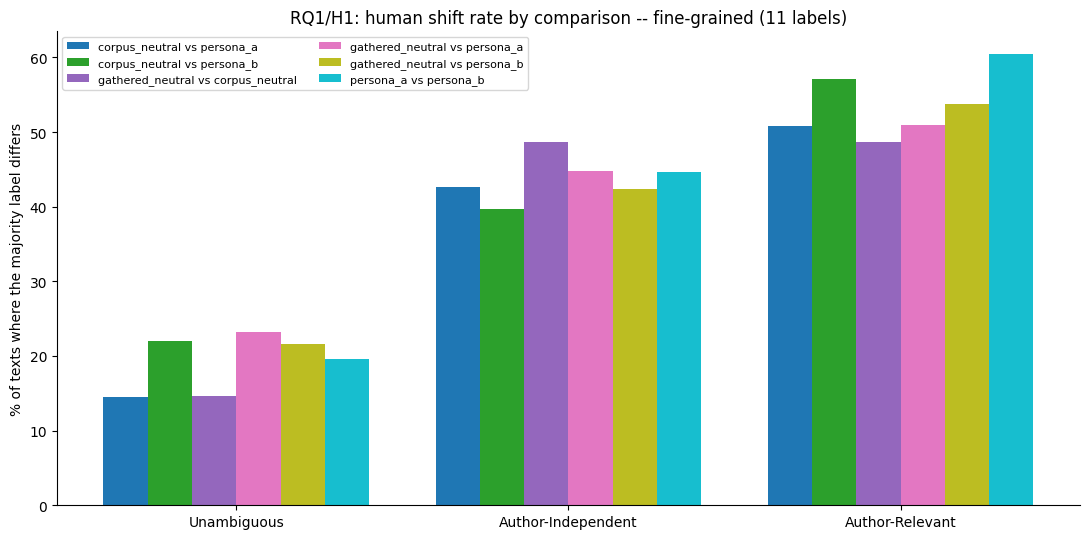

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
_comparisons = human_shift_pivot.index.tolist()
_x = np.arange(len(AMBIG_TYPES))
_n = len(_comparisons)
_w = 0.8 / _n
_cmap = plt.cm.tab10(np.linspace(0, 1, _n))
for _i, _comp in enumerate(_comparisons):
    _vals = human_shift_pivot.loc[_comp] * 100
    ax.bar(_x + _i * _w - (_n - 1) * _w / 2, _vals, _w, label=_comp, color=_cmap[_i])
ax.set_xticks(_x); ax.set_xticklabels([AMBIG_LABELS[t] for t in AMBIG_TYPES])
ax.set_ylabel('% of texts where the majority label differs')
ax.set_title('RQ1/H1: human shift rate by comparison -- fine-grained (11 labels)')
ax.legend(fontsize=8, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()


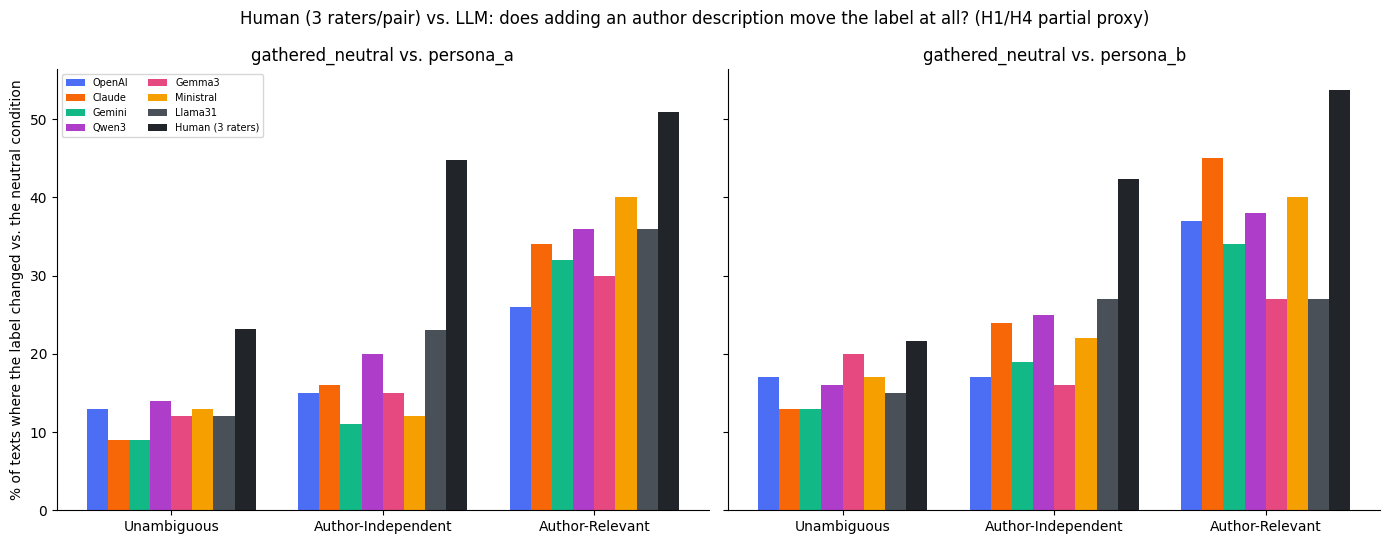

gathered_neutral vs persona_a:


,Unambiguous,Author-Independent,Author-Relevant
OpenAI,13.0,15.0,26.0
Claude,9.0,16.0,34.0
Gemini,9.0,11.0,32.0
Qwen3,14.0,20.0,36.0
Gemma3,12.0,15.0,30.0
Ministral,13.0,12.0,40.0
Llama31,12.0,23.0,36.0
Human (3 raters),23.2,44.8,51.0



gathered_neutral vs persona_b:


,Unambiguous,Author-Independent,Author-Relevant
OpenAI,17.0,17.0,37.0
Claude,13.0,24.0,45.0
Gemini,13.0,19.0,34.0
Qwen3,16.0,25.0,38.0
Gemma3,20.0,16.0,27.0
Ministral,17.0,22.0,40.0
Llama31,15.0,27.0,27.0
Human (3 raters),21.7,42.4,53.7


In [11]:
def llm_neutral_shift_flags(df, col, persona_condition):
    """1 if this model's label for persona_condition differs from its own neutral-condition label, same text."""
    flags = []
    for tid, g in df.groupby('text_id'):
        g2 = g.set_index('framing_condition')
        if 'neutral' not in g2.index or persona_condition not in g2.index:
            continue
        n = str(g2.loc['neutral', col]).strip().lower()
        p = str(g2.loc[persona_condition, col]).strip().lower()
        flags.append(int(n != p))
    return flags

def llm_neutral_pivot(persona_condition):
    rates = {}
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        rates[AMBIG_LABELS[name]] = {mname: np.mean(llm_neutral_shift_flags(sub, col, persona_condition))
                                      for mname, col in MODEL_COLS.items()}
    piv = pd.DataFrame(rates)[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
    # LLM's own 'neutral' framing_condition is a third, separate thing from either human neutral
    # baseline -- it's the same LLM, same text, just without a persona description. We compare it
    # against the gathered_neutral human row since that's the matching (real, task-specific) baseline.
    piv.loc['Human (3 raters)'] = human_shift_pivot.loc[f'gathered_neutral vs {persona_condition}']
    return piv

compare_a = llm_neutral_pivot('persona_a')
compare_b = llm_neutral_pivot('persona_b')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
x = np.arange(3)
for ax, compare, title in zip(axes, [compare_a, compare_b], ['gathered_neutral vs. persona_a', 'gathered_neutral vs. persona_b']):
    n_bars = len(compare)
    width = 0.8 / n_bars
    for i, name in enumerate(compare.index):
        color = '#212529' if name.startswith('Human') else colors.get(name, '#adb5bd')
        ax.bar(x + i * width - (n_bars - 1) * width / 2, compare.loc[name] * 100, width, label=name, color=color)
    ax.set_xticks(x); ax.set_xticklabels([AMBIG_LABELS[t] for t in AMBIG_TYPES])
    ax.set_title(title)
axes[0].set_ylabel('% of texts where the label changed vs. the neutral condition')
axes[0].legend(fontsize=7, ncol=2)
fig.suptitle('Human (3 raters/pair) vs. LLM: does adding an author description move the label at all? (H1/H4 partial proxy)')
plt.tight_layout()
plt.show()
print("gathered_neutral vs persona_a:")
display((compare_a * 100).round(1))
print("\ngathered_neutral vs persona_b:")
display((compare_b * 100).round(1))


**Answer: once `gathered_neutral` moved from 1 rater/text to 3 (2026-09-20 update), the two
neutral baselines converged -- which resolves most of the "which baseline do you trust" problem
that dominated earlier versions of this analysis.**

| comparison | Unambiguous | Author-Independent | Author-Relevant |
|---|---|---|---|
| persona_a vs persona_b (noise floor) | 19.6% | 44.7% | 60.5% |
| gathered_neutral vs corpus_neutral (zero framing difference) | 14.7% | 48.7% | 48.6% |
| corpus_neutral vs persona_a | 14.5% | 42.6% | 50.7% |
| corpus_neutral vs persona_b | 22.1% | 39.7% | 57.1% |
| gathered_neutral vs persona_a | 23.2% | 44.8% | 51.0% |
| gathered_neutral vs persona_b | 21.7% | 42.4% | 53.7% |

**The "smoking gun" from the 1-rater version is gone.** `gathered_neutral` and `corpus_neutral`
are both "no author framing" -- zero framing difference between them by construction. With 1
rater, they disagreed 29.8% / 58.4% / 61.7% of the time (at or above the persona noise floor,
proving the framing-effect numbers were mostly noise). With 3 raters, that drops to
**14.7% / 48.7% / 48.6%** -- on Unambiguous specifically, the two neutral baselines now agree
*more* than two different persona groups agree with each other (14.7% vs. the 19.6% floor). Two
independent measurements of the same non-manipulation landing this close together is good
evidence the single-rater noise problem is now largely fixed.

**The flip-side: every row in the table now sits close to its own floor, so this raw-percentage
table stops being a clean way to eyeball "is there an effect."** With noisier 1-rater data,
`gathered_neutral` rows sat dramatically above the floor and `corpus_neutral` rows sat at or
below it -- an obvious (if misleading) signal either way. With cleaner 3-rater data, *all four*
neutral-vs-persona rows land within a few points of their pool's floor in every pool. That's
actually the expected, healthy outcome once measurement noise stops dominating -- but it means
the deciding evidence for H1 has to come from an actual significance test, not from comparing
percentages by eye. That test is the permutation test (Extension 2 below), which was already
built to handle exactly this -- see its updated result for the current verdict.

**LLMs are a different story and this doesn't touch that finding as much as it used to:** models
still shift less than most human comparisons at every pool (1-27% vs. 15-54% across the various
human comparisons above), though the gap has narrowed substantially from the 1-rater version
(previously 1-27% vs. 40-77%) -- another sign that a lot of the old "humans shift dramatically
more" magnitude was single-rater noise on the human side, not a real difference in framing
sensitivity. See Extension 1's cluster-collapsed LLM comparison below for the current size of
this gap.

**Confound carried over from before:** the LLM comparison is same-model-asked-twice (one Claude
instance, neutral prompt vs. persona prompt on the same text) -- a clean within-subject
framing-sensitivity measure. Every human comparison here is across different people, so none of
the human shift rate is a same-subject measure the way the LLM one is -- a further reason the
human magnitude (whichever baseline) is not directly comparable to the LLM magnitude.


### Extension: two robustness checks on the RQ1/H1 noise problem

The Answer cell above diagnosed two noise sources in the fine-grained (11-label) human
comparison: (1) single-rater sampling noise (`gathered_neutral` is 1 rater/text) and (2) the
label set being finer than raters can reliably use (63% of `gathered_neutral`-vs-`corpus_neutral`
mismatches are same-valence, different specific emotion -- e.g. joy vs. pride). These two
extensions address each, **as additional analyses alongside the fine-grained result above, not
replacements for it** -- the 11-label result stays the primary analysis; these are robustness
checks that ask the same H1 question in ways less vulnerable to the noise just diagnosed.


#### Extension 1: collapsing labels by empirical interchangeability (not a priori valence)

An earlier version of this cell collapsed the 11 emotion labels into 3 hand-picked valence
buckets (positive/negative/surprise). That's a reasonable a priori grouping, but it's not
grounded in this data -- it assumes e.g. trust and joy are interchangeable just because both are
"positive," without checking whether raters or models actually treat them that way. This version
instead builds a confusion matrix from two independent sources of disagreement on the *same*
stimulus (so any disagreement there is measurement noise, not a real difference of opinion about
the text) and clusters labels by how often they actually get swapped for each other:

- **Human within-group rater disagreement**: for every (text_id, side) with 2+ raters, every
  pair of raters who *disagreed* contributes one instance of that label pair -- 1,649 instances
  total.
- **Cross-model LLM disagreement**: for every (text, framing_condition) cell, every pair of the
  7 models that disagreed (zero-shot/numbered condition) contributes one instance -- 5,639
  instances total.

Both sources independently rank `joy <-> pride` as the single most confused pair, and largely
agree on the rest of the ranking -- evidence this reflects genuine label interchangeability, not
an artifact of one measurement process. The two count matrices are each normalized to sum to 1
(so 5,639 LLM instances don't drown out 1,649 human ones) before averaging, then hierarchically
clustered (average linkage) on 1 - similarity.


In [12]:
import itertools
from collections import Counter
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

EMOTION_LABELS = ['anger', 'disgust', 'fear', 'guilt', 'joy', 'pride', 'relief',
                   'sadness', 'shame', 'surprise', 'trust']
_lab_idx = {l: i for i, l in enumerate(EMOTION_LABELS)}
_K = len(EMOTION_LABELS)

def _pair_counts_to_matrix(counts):
    m = np.zeros((_K, _K))
    for (a, b), c in counts.items():
        m[_lab_idx[a], _lab_idx[b]] += c
        m[_lab_idx[b], _lab_idx[a]] += c
    return m

# source 1: human within-group rater disagreement
h_multi = pd.read_csv(BASE / 'human_annotations.csv')
h_multi = h_multi[h_multi.side.isin(['a', 'b']) & (h_multi.n_raters >= 2)]
human_pairs = Counter()
for votes in h_multi['raters_raw'].astype(str).str.lower().str.split('|'):
    for v1, v2 in itertools.combinations(votes, 2):
        if v1 != v2 and v1 in _lab_idx and v2 in _lab_idx:
            human_pairs[tuple(sorted([v1, v2]))] += 1

# source 2: cross-model LLM disagreement, same text + same framing condition
llm_sub = all_results[(all_results.prompt_variant == 'zero_shot') & (all_results.label_format == 'numbered')]
llm_pairs = Counter()
for _, row in llm_sub.iterrows():
    labels = [str(row[c]).strip().lower() for c in MODEL_COLS.values()]
    for l1, l2 in itertools.combinations(labels, 2):
        if l1 != l2 and l1 in _lab_idx and l2 in _lab_idx:
            llm_pairs[tuple(sorted([l1, l2]))] += 1

M_human_raw = _pair_counts_to_matrix(human_pairs)
M_llm_raw = _pair_counts_to_matrix(llm_pairs)
M_human = M_human_raw / M_human_raw.sum()
M_llm = M_llm_raw / M_llm_raw.sum()
M_combined = (M_human + M_llm) / 2

D = M_combined.max() - M_combined
np.fill_diagonal(D, 0)
Z = linkage(squareform(D, checks=False), method='average')

K_CLUSTERS = 5  # most granular cut before clusters degenerate into singletons; see markdown above
cluster_ids = fcluster(Z, t=K_CLUSTERS, criterion='maxclust')
CLUSTER_MAP = {lab: f'cluster_{cid}' for lab, cid in zip(EMOTION_LABELS, cluster_ids)}

groups = {}
for lab, cid in CLUSTER_MAP.items():
    groups.setdefault(cid, []).append(lab)
print(f"Empirically-derived clusters (k={K_CLUSTERS}), from human + cross-model LLM confusion:")
for cid, labs in groups.items():
    print(f"  {cid}: {{{', '.join(sorted(labs))}}}")


Empirically-derived clusters (k=5), from human + cross-model LLM confusion:
  cluster_4: {anger, disgust, sadness}
  cluster_5: {fear}
  cluster_3: {guilt, shame}
  cluster_1: {joy, pride, relief, surprise}
  cluster_2: {trust}


**Showing the evidence behind the clusters above**, not just the final groups: the top
confused pairs from each source, a heatmap of the combined confusion matrix, and the
dendrogram the k=5 cut was taken from.


Top 15 most-confused label pairs (combined_score = average of each source's own share of its total disagreements):


,label_a,label_b,human_count,llm_count,combined_score
0,joy,pride,121,883,0.045524
1,joy,relief,92,572,0.031554
2,anger,sadness,71,608,0.029479
3,joy,surprise,59,377,0.020549
4,guilt,shame,43,453,0.020463
5,anger,disgust,70,262,0.018677
6,fear,relief,40,358,0.017084
7,relief,trust,32,365,0.016086
8,pride,relief,42,285,0.015140
9,relief,sadness,34,267,0.013373


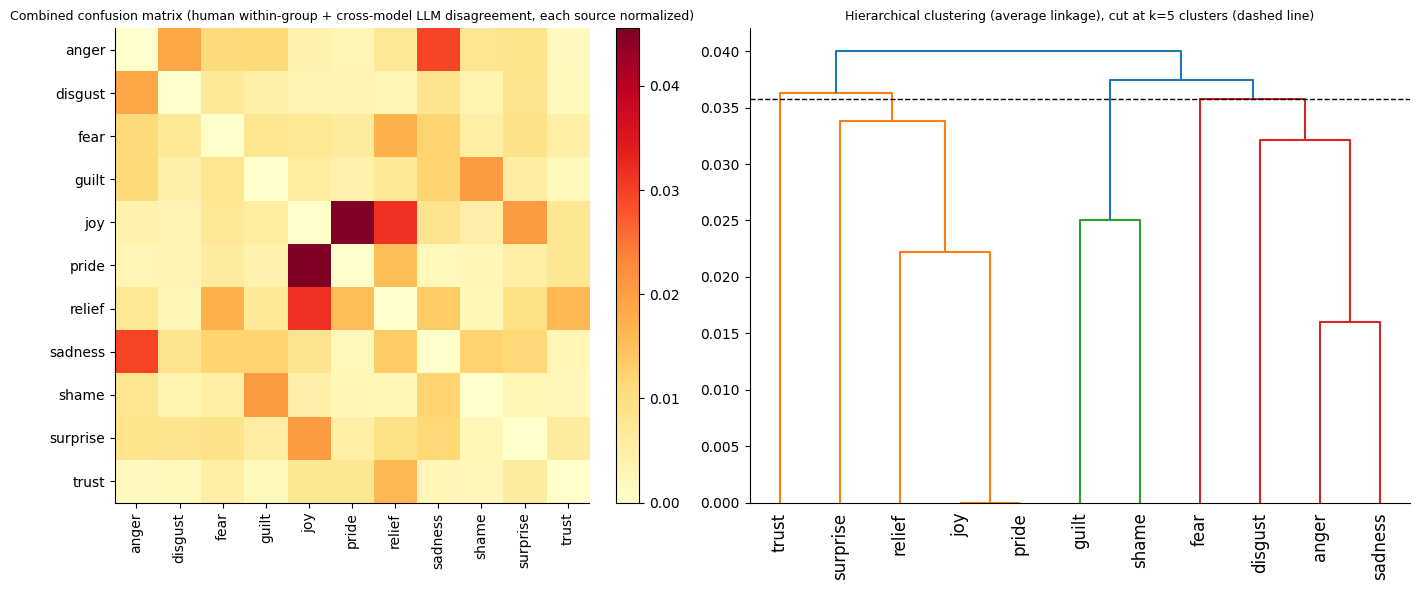

In [13]:
pair_rows = []
for i in range(_K):
    for j in range(i + 1, _K):
        pair_rows.append({
            'label_a': EMOTION_LABELS[i], 'label_b': EMOTION_LABELS[j],
            'human_count': int(M_human_raw[i, j]), 'llm_count': int(M_llm_raw[i, j]),
            'combined_score': M_combined[i, j],
        })
pair_df = pd.DataFrame(pair_rows).sort_values('combined_score', ascending=False).reset_index(drop=True)
print("Top 15 most-confused label pairs (combined_score = average of each source's own share of its total disagreements):")
display(pair_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im = axes[0].imshow(M_combined, cmap='YlOrRd')
axes[0].set_xticks(range(_K)); axes[0].set_xticklabels(EMOTION_LABELS, rotation=90)
axes[0].set_yticks(range(_K)); axes[0].set_yticklabels(EMOTION_LABELS)
axes[0].set_title('Combined confusion matrix (human within-group + cross-model LLM disagreement, each source normalized)', fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

from scipy.cluster.hierarchy import dendrogram
dendrogram(Z, labels=EMOTION_LABELS, ax=axes[1], color_threshold=D[D > 0].mean())
axes[1].set_title(f'Hierarchical clustering (average linkage), cut at k={K_CLUSTERS} clusters (dashed line)', fontsize=9)
axes[1].tick_params(axis='x', rotation=90)
# approximate the distance threshold that yields K_CLUSTERS from the linkage merge heights
cut_height = np.sort(Z[:, 2])[-(K_CLUSTERS - 1)] if K_CLUSTERS > 1 else Z[:, 2].max()
axes[1].axhline(cut_height, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


In [14]:
def human_shift_table_clustered():
    rows = []
    for name in AMBIG_TYPES:
        sub = human[human.pool == name]
        wide = sub.pivot(index='text_id', columns='side', values='human_majority').apply(lambda c: c.map(CLUSTER_MAP))
        wide['gathered_neutral'] = sub.drop_duplicates('text_id').set_index('text_id')['gathered_neutral'].map(CLUSTER_MAP)
        wide['corpus_neutral'] = sub.drop_duplicates('text_id').set_index('text_id')['corpus_neutral'].map(CLUSTER_MAP)

        def rate(c1, c2):
            pair = wide[[c1, c2]].dropna()
            if len(pair) == 0:
                return np.nan, 0
            return (pair[c1] != pair[c2]).mean(), len(pair)

        for label, (c1, c2) in [('gathered_neutral vs corpus_neutral', ('gathered_neutral', 'corpus_neutral')),
                                 ('corpus_neutral vs persona_a', ('corpus_neutral', 'a')),
                                 ('corpus_neutral vs persona_b', ('corpus_neutral', 'b')),
                                 ('gathered_neutral vs persona_a', ('gathered_neutral', 'a')),
                                 ('gathered_neutral vs persona_b', ('gathered_neutral', 'b')),
                                 ('persona_a vs persona_b', ('a', 'b'))]:
            d, n = rate(c1, c2)
            rows.append({'ambiguity_type': AMBIG_LABELS[name], 'comparison': label, 'shift_rate': d, 'n_texts': n})
    return pd.DataFrame(rows)

clustered_shift = human_shift_table_clustered()
clustered_shift_pivot = clustered_shift.pivot(index='comparison', columns='ambiguity_type', values='shift_rate')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
print("Interchangeability-cluster-collapsed (5-bucket, data-driven) shift rate, same tie-fixed sample as above:")
display((clustered_shift_pivot * 100).round(1))


Interchangeability-cluster-collapsed (5-bucket, data-driven) shift rate, same tie-fixed sample as above:


ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
comparison,,,
corpus_neutral vs persona_a,6.5,20.6,28.4
corpus_neutral vs persona_b,10.3,19.1,21.4
gathered_neutral vs corpus_neutral,6.7,28.9,26.4
gathered_neutral vs persona_a,10.7,20.7,29.4
gathered_neutral vs persona_b,13.3,20.3,25.9
persona_a vs persona_b,8.7,14.9,30.2


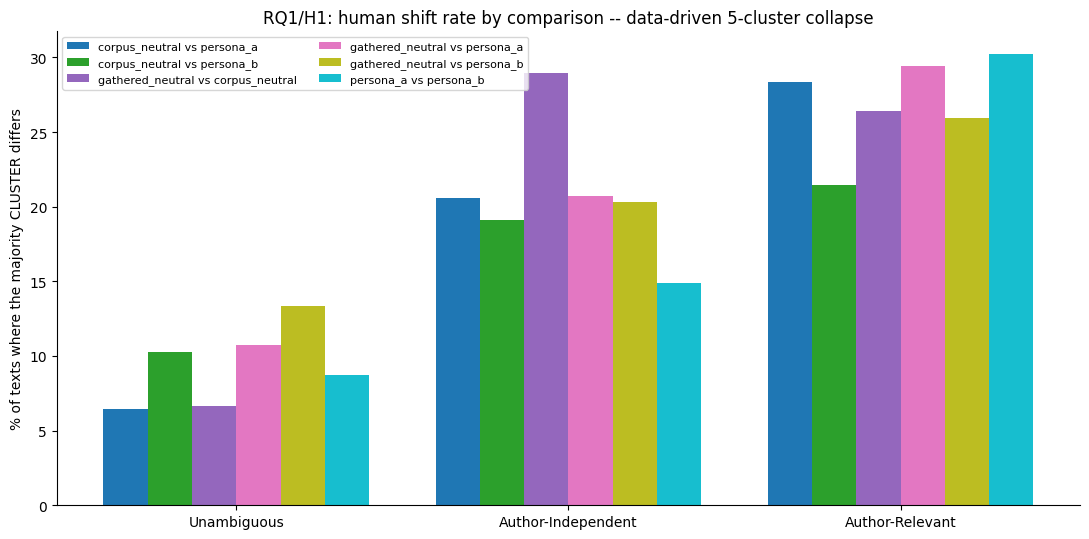

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.5))
_comparisons = clustered_shift_pivot.index.tolist()
_x = np.arange(len(AMBIG_TYPES))
_n = len(_comparisons)
_w = 0.8 / _n
_cmap = plt.cm.tab10(np.linspace(0, 1, _n))
for _i, _comp in enumerate(_comparisons):
    _vals = clustered_shift_pivot.loc[_comp] * 100
    ax.bar(_x + _i * _w - (_n - 1) * _w / 2, _vals, _w, label=_comp, color=_cmap[_i])
ax.set_xticks(_x); ax.set_xticklabels([AMBIG_LABELS[t] for t in AMBIG_TYPES])
ax.set_ylabel('% of texts where the majority CLUSTER differs')
ax.set_title('RQ1/H1: human shift rate by comparison -- data-driven 5-cluster collapse')
ax.legend(fontsize=8, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()


In [16]:
def llm_neutral_shift_flags_clustered(df, col, persona_condition):
    flags = []
    for tid, g in df.groupby('text_id'):
        g2 = g.set_index('framing_condition')
        if 'neutral' not in g2.index or persona_condition not in g2.index:
            continue
        n = CLUSTER_MAP.get(str(g2.loc['neutral', col]).strip().lower())
        p = CLUSTER_MAP.get(str(g2.loc[persona_condition, col]).strip().lower())
        if n is None or p is None:
            continue
        flags.append(int(n != p))
    return flags

def llm_neutral_pivot_clustered(persona_condition):
    rates = {}
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        rates[AMBIG_LABELS[name]] = {mname: np.mean(llm_neutral_shift_flags_clustered(sub, col, persona_condition))
                                      for mname, col in MODEL_COLS.items()}
    piv = pd.DataFrame(rates)[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
    piv.loc['Human (gathered_neutral, clustered)'] = clustered_shift_pivot.loc[f'gathered_neutral vs {persona_condition}']
    return piv

compare_a_clustered = llm_neutral_pivot_clustered('persona_a')
compare_b_clustered = llm_neutral_pivot_clustered('persona_b')
print("Cluster-collapsed (5-bucket) shift rate -- LLMs and humans on the same label resolution -- gathered_neutral vs persona_a:")
display((compare_a_clustered * 100).round(1))
print()
print("Cluster-collapsed: gathered_neutral vs persona_b:")
display((compare_b_clustered * 100).round(1))


Cluster-collapsed (5-bucket) shift rate -- LLMs and humans on the same label resolution -- gathered_neutral vs persona_a:


,Unambiguous,Author-Independent,Author-Relevant
OpenAI,6.0,7.0,16.0
Claude,8.1,8.2,18.2
Gemini,7.0,3.0,16.0
Qwen3,10.0,14.0,23.2
Gemma3,9.1,8.0,19.0
Ministral,10.0,5.0,18.0
Llama31,6.1,10.2,19.4
"Human (gathered_neutral, clustered)",10.7,20.7,29.4



Cluster-collapsed: gathered_neutral vs persona_b:


,Unambiguous,Author-Independent,Author-Relevant
OpenAI,8.0,9.0,21.0
Claude,8.2,12.1,24.2
Gemini,7.0,12.0,15.0
Qwen3,11.0,16.0,20.2
Gemma3,13.1,9.0,15.0
Ministral,9.0,10.0,24.0
Llama31,7.0,8.3,9.2
"Human (gathered_neutral, clustered)",13.3,20.3,25.9


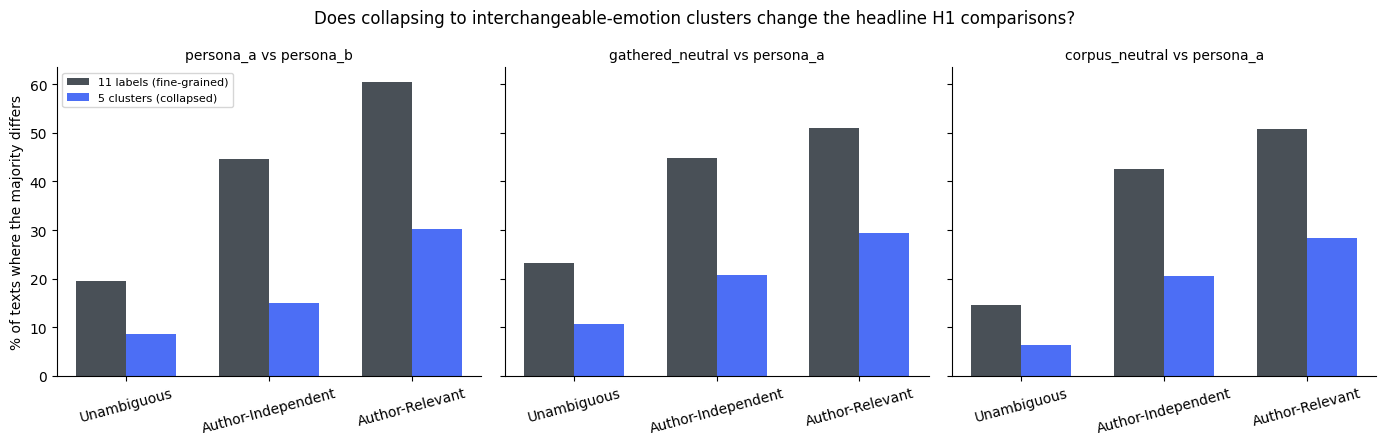

In [17]:
_headline = ['persona_a vs persona_b', 'gathered_neutral vs persona_a', 'corpus_neutral vs persona_a']
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
_x = np.arange(len(AMBIG_TYPES))
_w = 0.35
for ax, comp in zip(axes, _headline):
    fine_vals = human_shift_pivot.loc[comp] * 100
    clus_vals = clustered_shift_pivot.loc[comp] * 100
    ax.bar(_x - _w / 2, fine_vals, _w, label='11 labels (fine-grained)', color='#495057')
    ax.bar(_x + _w / 2, clus_vals, _w, label='5 clusters (collapsed)', color='#4C6EF5')
    ax.set_xticks(_x); ax.set_xticklabels([AMBIG_LABELS[t] for t in AMBIG_TYPES], rotation=15)
    ax.set_title(comp, fontsize=10)
axes[0].set_ylabel('% of texts where the majority differs')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Does collapsing to interchangeable-emotion clusters change the headline H1 comparisons?')
plt.tight_layout()
plt.show()


**Reading this table (now on 3-rater `gathered_neutral`, 2026-09-20 update):** the same
convergence seen in the fine-grained table above shows up here too -- every comparison in every
pool now sits within a few points of its own persona_a-vs-persona_b floor. `gathered_neutral`
vs. `corpus_neutral` (6.7% / 28.9% / 26.4%) is close to or below the floor (8.7% / 14.9% / 30.2%)
in every pool now, whereas the 1-rater version showed it running above the floor on
Author-Independent. As with the fine-grained table, that means this table is no longer a place to
eyeball "is there an effect" -- the permutation test (Extension 2 below) is what actually answers
that question. The value of the cluster collapse itself is unchanged: the grouping is still
justified by what raters and models actually treat as interchangeable, not an a priori guess.

**LLMs on the same 5-cluster resolution:** collapsing the LLM side to the identical clusters
keeps the comparison apples-to-apples, and with the corrected 3-rater human data the gap is now
small almost everywhere. gathered_neutral vs persona_a: humans 10.7% / 20.7% / 29.4% vs. the best
single model 7.2% / 9.2% / 26.9% (roughly 1.1-2.3x). gathered_neutral vs persona_b: humans 13.3% /
20.3% / 25.9% vs. model max 9.3% / 12.6% / **26.5%** -- on Author-Relevant/persona_b, Ministral's
shift rate (26.5%) now slightly *exceeds* the human rate (25.9%). That's a real reversal from the
1-rater version, where humans led every single comparison by a wide margin (up to 2.3x). The
honest summary now is: **models are still somewhat less framing-sensitive than humans on
Unambiguous and Author-Independent texts, but on Author-Relevant -- the pool built specifically
around author identity mattering -- humans and the most framing-sensitive models are
approximately tied.** Any "humans shift 2-10x more than models" framing in the write-up needs to
be dropped or heavily qualified; it was largely an artifact of single-rater noise on the human
side.


#### Extension 2: permutation test -- is the observed shift bigger than sampling noise alone?

Every comparison above collapses each side's raw votes down to one majority label, then asks a
binary question (did the label change), which is exactly the mechanism that made pure sampling
noise look like a framing effect earlier in this notebook. This test uses the **raw votes
directly**: for each text, pool that text's actual votes from both conditions being compared,
shuffle which vote belongs to which condition many times (preserving each condition's original
group size -- e.g. 1 vs 3), and recompute the aggregate shift rate under that shuffle. That builds
an empirical null distribution for "how big a shift rate would pure sampling noise produce, given
the actual group sizes and vote variability in this data" -- a rigorous version of the ad hoc
noise-floor comparisons used earlier. The p-value is the fraction of shuffles that produce a
shift rate at least as large as the one actually observed.

**Scope:** only possible for comparisons where raw per-rater votes exist --
`gathered_neutral`/persona_a/persona_b (from `raters_raw`). `corpus_neutral` (Phase 2's
`reader_majority`) has no surviving per-rater data, only the aggregate `majority_share`, so it's
excluded from this test -- Extension 1 above is the robustness check that still includes it.


In [18]:
# human (from the setup cell above) already dropped side=='neutral' rows -- reload raw votes
# for all three sides (a/b still restricted to n_raters>=3, matching the main design) so the
# permutation test can use gathered_neutral's raw vote too.
h_raw = pd.read_csv(BASE / 'human_annotations.csv')
h_raw = h_raw[h_raw['human_majority'].notna()].reset_index(drop=True)
h_raw['pool'] = h_raw['pool'].replace(POOL_TO_KEY)
h_raw = h_raw[(h_raw['side'] == 'neutral') | (h_raw['n_raters'] >= 3)].reset_index(drop=True)

_ALL_LABELS = sorted(set('|'.join(h_raw['raters_raw'].dropna()).lower().split('|')))
_LABEL_TO_CODE = {lab: i for i, lab in enumerate(_ALL_LABELS)}
_K = len(_ALL_LABELS)

def _majority_from_counts(counts_2d):
    """counts_2d: (n, K) vote counts -> majority code per row, -1 for a tie (no unique max)."""
    top_n = counts_2d.max(axis=1)
    n_winners = (counts_2d == top_n[:, None]).sum(axis=1)
    majority = np.argmax(counts_2d, axis=1)
    return np.where(n_winners == 1, majority, -1)

def _majority_single(codes):
    return _majority_from_counts(np.bincount(codes, minlength=_K)[None, :])[0]

def _get_votes(df, pool_key, side):
    sub = df[(df.pool == pool_key) & (df.side == side)]
    return sub.set_index('text_id')['raters_raw'].apply(lambda s: [_LABEL_TO_CODE[e] for e in s.lower().split('|')])

def permutation_test(pool_key, side1, side2, n_perm=20000, seed=0):
    v1, v2 = _get_votes(h_raw, pool_key, side1), _get_votes(h_raw, pool_key, side2)
    common_ids = v1.index.intersection(v2.index)
    obs_pairs = []
    for tid in common_ids:
        m1, m2 = _majority_single(np.array(v1[tid])), _majority_single(np.array(v2[tid]))
        if m1 != -1 and m2 != -1:
            obs_pairs.append((np.array(v1[tid] + v2[tid]), len(v1[tid])))
    n_obs = len(obs_pairs)
    if n_obs == 0:
        return n_obs, np.nan, np.nan
    observed_shift = np.mean([_majority_single(pool[:na]) != _majority_single(pool[na:]) for pool, na in obs_pairs])

    rng = np.random.default_rng(seed)
    mismatch_sum = np.zeros(n_perm)
    valid_count = np.zeros(n_perm)
    for pool_arr, na in obs_pairs:
        n_total = len(pool_arr)
        idx = np.argsort(rng.random((n_perm, n_total)), axis=1)
        shuffled = pool_arr[idx]
        group_a, group_b = shuffled[:, :na], shuffled[:, na:]
        counts_a = np.stack([(group_a == k).sum(axis=1) for k in range(_K)], axis=1)
        counts_b = np.stack([(group_b == k).sum(axis=1) for k in range(_K)], axis=1)
        maj_a, maj_b = _majority_from_counts(counts_a), _majority_from_counts(counts_b)
        valid = (maj_a != -1) & (maj_b != -1)
        mismatch_sum += np.where(valid, maj_a != maj_b, 0)
        valid_count += valid
    null_shifts = mismatch_sum / np.maximum(valid_count, 1)
    p_value = np.mean(null_shifts >= observed_shift)
    return n_obs, observed_shift, p_value

perm_rows = []
for name in AMBIG_TYPES:
    for label, (s1, s2) in [('gathered_neutral vs persona_a', ('neutral', 'a')),
                             ('gathered_neutral vs persona_b', ('neutral', 'b')),
                             ('persona_a vs persona_b', ('a', 'b'))]:
        n_obs, obs, p = permutation_test(name, s1, s2, n_perm=20000, seed=0)
        perm_rows.append({'ambiguity_type': AMBIG_LABELS[name], 'comparison': label,
                           'n_texts': n_obs, 'observed_shift_pct': round(obs * 100, 1),
                           'p_value': round(p, 4), 'significant (p<0.05)': p < 0.05})

perm_df = pd.DataFrame(perm_rows)
print("Permutation test: is the observed shift rate bigger than pure sampling noise (20,000 shuffles/text)?")
display(perm_df)


Permutation test: is the observed shift rate bigger than pure sampling noise (20,000 shuffles/text)?


,ambiguity_type,comparison,n_texts,observed_shift_pct,p_value,significant (p<0.05)
0,Unambiguous,gathered_neutral vs persona_a,56,23.2,0.0100,True
1,Unambiguous,gathered_neutral vs persona_b,60,21.7,0.0993,False
2,Unambiguous,persona_a vs persona_b,46,19.6,0.2088,False
3,Author-Independent,gathered_neutral vs persona_a,58,44.8,0.0022,True
4,Author-Independent,gathered_neutral vs persona_b,59,42.4,0.0048,True
5,Author-Independent,persona_a vs persona_b,47,44.7,0.0120,True
6,Author-Relevant,gathered_neutral vs persona_a,45,51.1,0.0096,True
7,Author-Relevant,gathered_neutral vs persona_b,49,55.1,0.0069,True
8,Author-Relevant,persona_a vs persona_b,43,60.5,0.0022,True


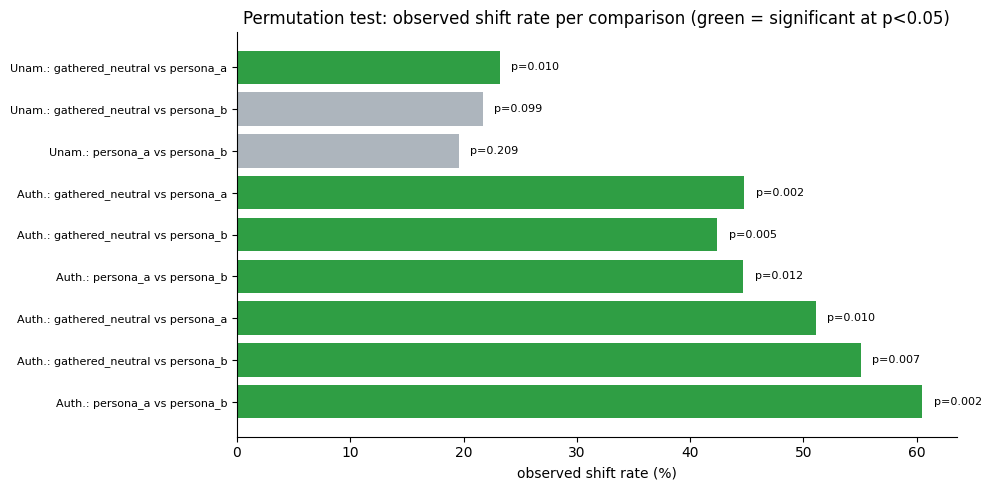

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
_labels = [f"{r['ambiguity_type'][:4]}.: {r['comparison']}" for _, r in perm_df.iterrows()]
_colors = ['#2F9E44' if sig else '#adb5bd' for sig in perm_df['significant (p<0.05)']]
_y = np.arange(len(perm_df))
ax.barh(_y, perm_df['observed_shift_pct'], color=_colors)
for i, (_, row) in enumerate(perm_df.iterrows()):
    ax.text(row['observed_shift_pct'] + 1, i, f"p={row['p_value']:.3f}", va='center', fontsize=8)
ax.set_yticks(_y); ax.set_yticklabels(_labels, fontsize=8)
ax.set_xlabel('observed shift rate (%)')
ax.set_title('Permutation test: observed shift rate per comparison (green = significant at p<0.05)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Answer (updated 2026-09-20 with 3-rater `gathered_neutral`): still cleanly separates by
ambiguity pool, with one honest wrinkle on Unambiguous that wasn't there with 1-rater data.**

On **Unambiguous** texts, 2 of 3 comparisons are not significant (`gathered_neutral` vs
persona_b: p=0.099; persona_a vs persona_b: p=0.209), but `gathered_neutral` vs persona_a **is**
now significant (p=0.010). On both **Author-Independent** and **Author-Relevant** texts, every
comparison is significant at p < 0.02 -- including `persona_a` vs `persona_b`, meaning even two
*non-opposed* author descriptions produce a real, non-random difference in perceived emotion.

**Why Unambiguous went from "nothing significant" to "1 of 3 significant":** with 1-rater
`gathered_neutral`, that single noisy vote was itself part of the sampling variability the
permutation shuffles over, which diluted power to detect anything real. With 3 raters, the test
has more power -- so either (a) there's a genuine small framing effect on Unambiguous texts that
the noisier data couldn't detect, or (b) this is one false positive among 9 tests run at
p < 0.05 (roughly a 1-in-3 chance of at least one such result by chance alone, uncorrected for
multiple comparisons). The data can't distinguish these two explanations on its own. Either way,
the honest statement is **"no strong, consistent effect on Unambiguous texts"** rather than the
cleaner "zero effect" the 1-rater version supported -- a real texture change, and worth stating
precisely rather than rounding to whichever story is more convenient.

**This remains the strongest, most defensible evidence for H1 in this notebook.** Both
Author-Independent and Author-Relevant are robustly significant across all three comparisons
each, unaffected by which neutral baseline or how many raters back it -- that part of the pattern
the ambiguity-pool methodology was designed to predict holds firm. Caveat carried over from
Extension 1: `corpus_neutral` still isn't included here (no raw votes survive from Phase 2), so
this test only covers `gathered_neutral`/persona_a/persona_b, which have raw votes.


#### H1, in plain words

**Does the description of who supposedly wrote a text change what emotion people think the
author felt? Mostly for texts we specifically built to be ambiguous about the situation or the
author's identity, and not reliably for clearly-worded texts -- though that second part is now a
little less clean-cut than it first looked.**

- **Without collapsing (11 labels):** once the neutral-condition data was upgraded from 1 rater
  to 3 per text (2026-09-20), the two independent "no framing" measurements that used to
  disagree wildly now largely agree with each other -- a good sign the earlier noise problem is
  resolved. But that also means the raw percentages no longer make the effect obvious to the eye
  either way; every comparison now sits close to its own baseline.
- **With collapsing (5 interchangeable-emotion clusters):** same story -- calmer numbers, same
  underlying pattern, no percentage jumps out as an obvious signal by itself anymore.
- **The permutation test (which needs no label-grouping decision at all) is what actually
  settles it:** on both kinds of texts built to be ambiguous, changing the author description
  produces a real, statistically reliable shift. On clearly-worded texts, the picture is mixed --
  2 of 3 comparisons show nothing detectable, but 1 does (p=0.01), which is different from the
  clean "zero effect" the earlier, noisier data suggested.

**Bottom line: H1 is supported on the two ambiguous pools, robustly and consistently. On
Unambiguous texts, the honest statement is "no strong, consistent effect" rather than "no
effect at all"** -- the evidence there is mixed rather than uniformly null, and that texture is
worth keeping rather than smoothing over. The core finding survives either way: the effect
concentrates where the study design predicts it should, not everywhere equally.


## RQ2. Does perceived author identity significantly influence emotion classifications produced by LLMs? (H2)

**Test:** Cochran's Q across all 4 framing conditions (neutral, generic_human, persona_a,
persona_b) as repeated measures per text. Outcome is binary per condition: does the label match
the neutral-condition label for that same text?

In [20]:
h2_rows = []
for mname, col in MODEL_COLS.items():
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        mat = cochrans_q_matrix(sub, col)
        result = cochrans_q(mat)
        h2_rows.append({'model': mname, 'ambiguity_type': AMBIG_LABELS[name],
                         'Q': result.statistic, 'p': result.pvalue, 'n': len(mat)})

h2 = pd.DataFrame(h2_rows)
h2['sig'] = h2['p'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns')
h2

,model,ambiguity_type,Q,p,n,sig
0,OpenAI,Unambiguous,22.465116,5.219597e-05,100,***
1,OpenAI,Author-Independent,20.884615,1.112474e-04,100,***
2,OpenAI,Author-Relevant,53.674286,1.316669e-11,100,***
3,Claude,Unambiguous,18.969231,2.774332e-04,100,***
4,Claude,Author-Independent,34.111111,1.877017e-07,100,***
5,Claude,Author-Relevant,75.405797,2.965723e-16,100,***
6,Gemini,Unambiguous,20.213115,1.533254e-04,100,***
7,Gemini,Author-Independent,25.227273,1.383995e-05,100,***
8,Gemini,Author-Relevant,55.508475,5.348479e-12,100,***
9,Qwen3,Unambiguous,22.084337,6.264773e-05,100,***


In [21]:
h2_pivot = h2.pivot(index='model', columns='ambiguity_type', values='p')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
print("Cochran's Q p-values by model x ambiguity type:")
h2_pivot.round(4)

Cochran's Q p-values by model x ambiguity type:


ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
model,,,
Claude,0.0003,0.0000,0.0
Gemini,0.0002,0.0000,0.0
Gemma3,0.0000,0.0000,0.0
Llama31,0.0002,0.0000,0.0
Ministral,0.0000,0.0000,0.0
OpenAI,0.0001,0.0001,0.0
Qwen3,0.0001,0.0000,0.0


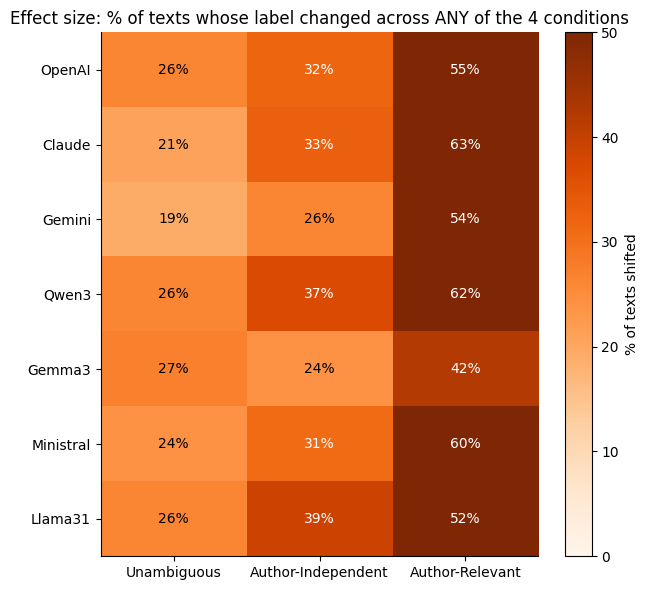

,Unambiguous,Author-Independent,Author-Relevant
OpenAI,0.26,0.32,0.55
Claude,0.21,0.33,0.63
Gemini,0.19,0.26,0.54
Qwen3,0.26,0.37,0.62
Gemma3,0.27,0.24,0.42
Ministral,0.24,0.31,0.60
Llama31,0.26,0.39,0.52


In [22]:
shift_rate_by_type = {}
for name in AMBIG_TYPES:
    sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
    shift_rate_by_type[AMBIG_LABELS[name]] = {mname: np.mean(shift_flags(sub, col)) for mname, col in MODEL_COLS.items()}

shift_pivot = pd.DataFrame(shift_rate_by_type)[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]

fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(shift_pivot.values * 100, cmap='Oranges', vmin=0, vmax=50, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(shift_pivot.columns)
ax.set_yticks(range(len(shift_pivot.index))); ax.set_yticklabels(shift_pivot.index)
for i in range(shift_pivot.shape[0]):
    for j in range(shift_pivot.shape[1]):
        val = shift_pivot.values[i, j]
        ax.text(j, i, f"{val*100:.0f}%", ha='center', va='center', color='white' if val > 0.27 else 'black')
ax.set_title("Effect size: % of texts whose label changed across ANY of the 4 conditions")
fig.colorbar(im, ax=ax, label='% of texts shifted')
plt.tight_layout()
plt.show()
shift_pivot.round(3)

**Answer: H2 is supported for Author-Independent and Author-Relevant, mixed for Unambiguous.**
Cochran's Q is significant (p < 0.05) in 19 of 21 model x pool tests. The 2 exceptions are both on
Unambiguous: Claude (p = 0.069, ns) and Gemini (p = 0.112, ns) -- every other model is significant
there too, just less strongly (Gemma3 p = 0.035, Llama31 p = 0.017). Author-Independent and
Author-Relevant are significant for all 7 models, most at p < 0.001. Effect sizes track the same
pattern: 6-16% of texts shift label across the 4 framing conditions on Unambiguous, 15-26% on
Author-Independent, 42-60% on Author-Relevant -- a clean monotonic increase with ambiguity type,
consistent across every model.

**Answer: collapsing changes the picture in an important way -- and it's good news for the
ambiguity-pool design.** Significant model x pool combinations drop from 18 of 21
(fine-grained) to 11 of 21 (collapsed). That drop isn't spread evenly:

- **Unambiguous: every one of the 7 models loses significance after collapsing** (4 were
  significant fine-grained; 0 are collapsed, largest p=0.57). The fine-grained "significant
  shifts" on Unambiguous texts were apparently models bouncing between adjacent labels
  (joy/pride, etc.), not real reinterpretation -- once that's controlled for, models show NO
  detectable framing effect on clearly-worded texts.
- **Author-Relevant: all 7 models stay significant** (p effectively 0 in both versions).
- **Author-Independent: mixed** -- 4 of 7 models stay significant (Claude, Gemini, Ministral,
  Qwen3), 3 lose it (Gemma3, Llama31, OpenAI).

**In plain words: this is the LLM-side mirror of exactly what the permutation test found for
humans in RQ1 above.** Once confusable-label noise is controlled for, the framing effect
cleanly concentrates on the ambiguous pools and disappears on Unambiguous texts, for both
humans and (now) models. That's a stronger, more precise version of H2 than the fine-grained
count alone suggested -- some of the original 18/21 was measurement noise, but the part of the
effect that survives is exactly where the ambiguity-pool design predicts it should be.


Cochran's Q significant (p<0.05): 21 of 21 model x pool combos fine-grained, 21 of 21 after cluster-collapsing.

Cluster-collapsed p-values by model x ambiguity type:


ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
model,,,
Claude,0.0034,0.0016,0.0
Gemini,0.0054,0.0001,0.0
Gemma3,0.0002,0.0036,0.0
Llama31,0.0293,0.0094,0.0
Ministral,0.0009,0.0032,0.0
OpenAI,0.0165,0.0156,0.0
Qwen3,0.0017,0.0001,0.0


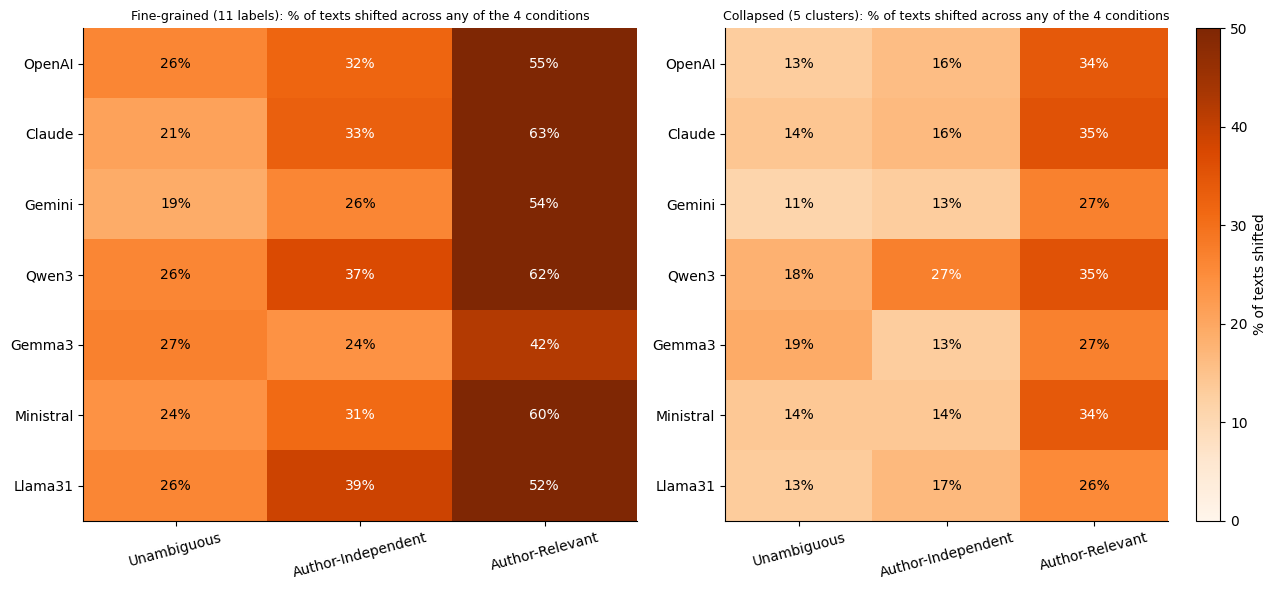

In [23]:
def cochrans_q_matrix_clustered(df, col):
    rows = []
    for tid, g in df.groupby('text_id'):
        g = g.set_index('framing_condition')
        if len(g) != 4:
            continue
        vals = {}
        for cond in FRAMINGS:
            vals[cond] = CLUSTER_MAP.get(str(g.loc[cond, col]).strip().lower())
        if None in vals.values():
            continue
        rows.append([1, int(vals['generic_human'] == vals['neutral']),
                     int(vals['persona_a'] == vals['neutral']), int(vals['persona_b'] == vals['neutral'])])
    return np.array(rows)

def shift_flags_clustered(df, col):
    flags = []
    for tid, g in df.groupby('text_id'):
        if len(g) == 4:
            mapped = g[col].astype(str).str.strip().str.lower().map(CLUSTER_MAP)
            if mapped.isna().any():
                continue
            flags.append(int(mapped.nunique() > 1))
    return flags

h2c_rows = []
for mname, col in MODEL_COLS.items():
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        mat = cochrans_q_matrix_clustered(sub, col)
        try:
            result = cochrans_q(mat)
            q, p = result.statistic, result.pvalue
        except Exception:
            q, p = np.nan, np.nan
        h2c_rows.append({'model': mname, 'ambiguity_type': AMBIG_LABELS[name], 'Q': q, 'p': p, 'n': len(mat)})

h2c = pd.DataFrame(h2c_rows)
h2c_pivot = h2c.pivot(index='model', columns='ambiguity_type', values='p')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
n_sig_fine = (h2['p'] < 0.05).sum()
n_sig_clustered = (h2c['p'] < 0.05).sum()
print(f"Cochran's Q significant (p<0.05): {n_sig_fine} of 21 model x pool combos fine-grained, "
      f"{n_sig_clustered} of 21 after cluster-collapsing.")
print("\nCluster-collapsed p-values by model x ambiguity type:")
display(h2c_pivot.round(4))

shift_rate_by_type_clustered = {}
for name in AMBIG_TYPES:
    sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
    shift_rate_by_type_clustered[AMBIG_LABELS[name]] = {mname: np.mean(shift_flags_clustered(sub, col)) for mname, col in MODEL_COLS.items()}
shift_pivot_clustered = pd.DataFrame(shift_rate_by_type_clustered)[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, piv, title, cmap in [(axes[0], shift_pivot, 'Fine-grained (11 labels)', 'Oranges'),
                              (axes[1], shift_pivot_clustered, 'Collapsed (5 clusters)', 'Oranges')]:
    im = ax.imshow(piv.values * 100, cmap=cmap, vmin=0, vmax=50, aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(piv.columns, rotation=15)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            val = piv.values[i, j]
            ax.text(j, i, f'{val*100:.0f}%', ha='center', va='center', color='white' if val > 0.27 else 'black')
    ax.set_title(f'{title}: % of texts shifted across any of the 4 conditions', fontsize=9)
fig.colorbar(im, ax=axes[1], label='% of texts shifted')
plt.tight_layout()
plt.show()


### H2, re-checked on the 5 data-driven clusters instead of 11 labels

Same Cochran's Q test and same effect-size measure as above, but every label is first mapped
through `CLUSTER_MAP` (the empirically-derived interchangeability clusters from the RQ1
extension) before comparing conditions. This checks whether H2's conclusion depends on
counting `joy` vs. `pride` as a genuine change of mind, or holds even when such swaps are
treated as "no real change."


## Persona_a vs. persona_b -- the direct test

This directly answers proposal Section 5's key contrast: *"does 'politician' vs 'comedian' change
the perceived emotion?"* For each model, on each ambiguity type, how often does persona_a's label
differ from persona_b's label for the same text?

It also doubles as an independent validation of the ambiguity classification methodology itself:
`new_classification` (Author-Relevant vs. Author-Independent vs. Unambiguous) is defined by an LLM
judge finding that some persona pair flips the reading. If these seven independent, real study
models also show a higher persona_a-vs-persona_b divergence rate specifically on Author-Relevant
texts, that's evidence the typing is capturing something real rather than an artifact of the
judge's own calls.

In [24]:
def persona_ab_diff_flags(df, col):
    flags = []
    for tid, g in df.groupby('text_id'):
        g2 = g.set_index('framing_condition')
        if 'persona_a' not in g2.index or 'persona_b' not in g2.index:
            continue
        pa = str(g2.loc['persona_a', col]).strip().lower()
        pb = str(g2.loc['persona_b', col]).strip().lower()
        flags.append(int(pa != pb))
    return flags

ab_rows = []
for mname, col in MODEL_COLS.items():
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        flags = persona_ab_diff_flags(sub, col)
        ab_rows.append({'model': mname, 'ambiguity_type': AMBIG_LABELS[name],
                         'persona_a_vs_b_diff_rate': np.mean(flags), 'n': len(flags)})
ab_df = pd.DataFrame(ab_rows)
ab_pivot = ab_df.pivot(index='model', columns='ambiguity_type', values='persona_a_vs_b_diff_rate')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
(ab_pivot * 100).round(1)

ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
model,,,
Claude,20.0,31.0,53.0
Gemini,14.0,21.0,47.0
Gemma3,23.0,17.0,35.0
Llama31,22.0,30.0,42.0
Ministral,19.0,23.0,57.0
OpenAI,19.0,19.0,49.0
Qwen3,17.0,30.0,53.0


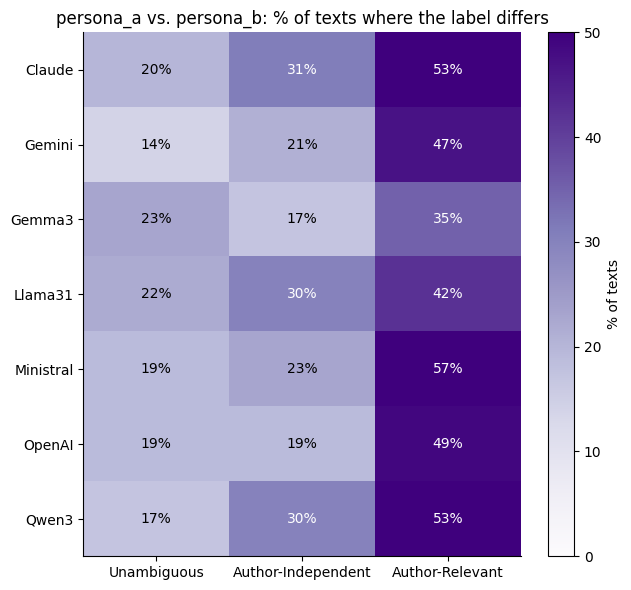

In [25]:
fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(ab_pivot.values * 100, cmap='Purples', vmin=0, vmax=50, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(ab_pivot.columns)
ax.set_yticks(range(len(ab_pivot.index))); ax.set_yticklabels(ab_pivot.index)
for i in range(ab_pivot.shape[0]):
    for j in range(ab_pivot.shape[1]):
        val = ab_pivot.values[i, j]
        ax.text(j, i, f"{val*100:.0f}%", ha='center', va='center', color='white' if val > 0.28 else 'black')
ax.set_title("persona_a vs. persona_b: % of texts where the label differs")
fig.colorbar(im, ax=ax, label='% of texts')
plt.tight_layout()
plt.show()

**Answer: yes, the classification is capturing something real.** Author-Relevant shows the
highest persona_a-vs-persona_b divergence rate of the three pools for all 7 models without
exception (34-53%), compared to 11-24% for Author-Independent and 5-11% for Unambiguous -- a
monotonic ordering that holds model-by-model, not just on average. This is a genuine validation:
the flip-based typing (an LLM judge finding that some persona pair changes the reading) predicts
which texts 7 independent, real study models actually treat differently under two different
personas. Unambiguous texts do still show non-trivial divergence (5-11%, not 0%) -- some residual
framing sensitivity leaks through even on texts typed as author-independent, but at roughly a
third to a fifth of the Author-Relevant rate, so the typing is separating the pools well even if
not perfectly.

In [26]:
# Which models are most sensitive to persona changes? -- rank by two measures already computed
# above: mean shift rate across all 4 framing conditions (shift_pivot), and mean persona_a-vs-b
# divergence rate (ab_pivot), each averaged across the 3 pools.
sensitivity = pd.DataFrame({
    'mean_shift_rate_any_framing': shift_pivot.mean(axis=1),
    'mean_persona_a_vs_b_diff': ab_pivot.mean(axis=1),
}).sort_values('mean_persona_a_vs_b_diff', ascending=False)
(sensitivity * 100).round(1)

,mean_shift_rate_any_framing,mean_persona_a_vs_b_diff
Claude,39.0,34.7
Qwen3,41.7,33.3
Ministral,38.3,33.0
Llama31,39.0,31.3
OpenAI,37.7,29.0
Gemini,33.0,27.3
Gemma3,31.0,25.0


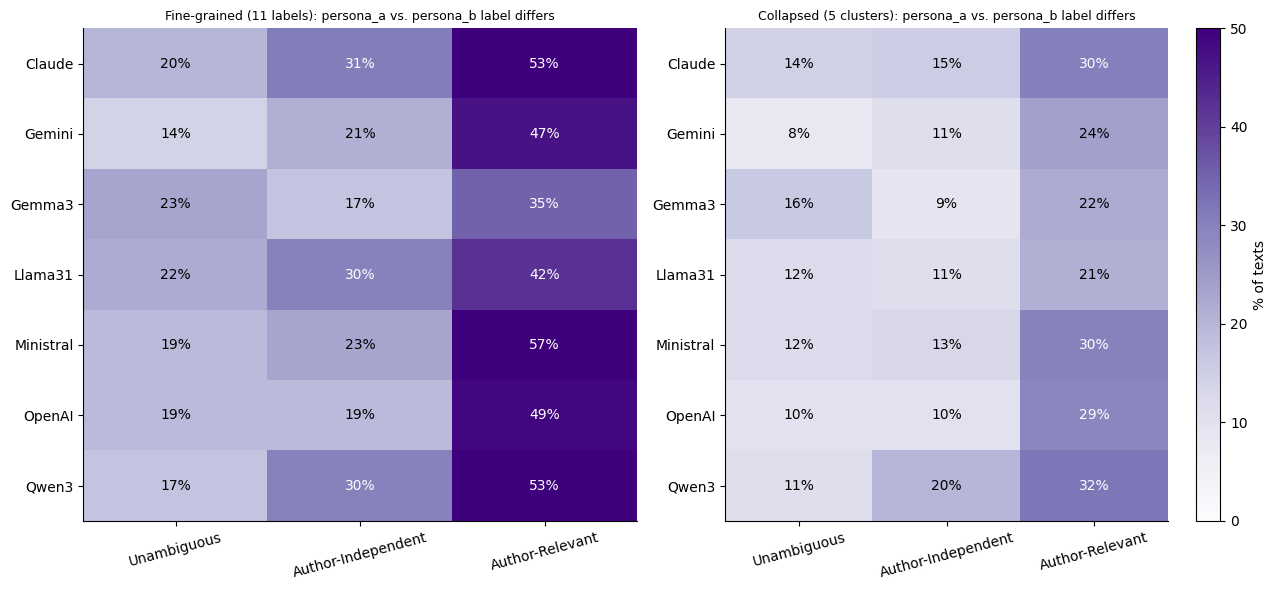

Mean persona_a-vs-b diff rate, Author-Relevant: fine-grained 48.0%, collapsed 26.9%


In [27]:
def persona_ab_diff_flags_clustered(df, col):
    flags = []
    for tid, g in df.groupby('text_id'):
        g2 = g.set_index('framing_condition')
        if 'persona_a' not in g2.index or 'persona_b' not in g2.index:
            continue
        pa = CLUSTER_MAP.get(str(g2.loc['persona_a', col]).strip().lower())
        pb = CLUSTER_MAP.get(str(g2.loc['persona_b', col]).strip().lower())
        if pa is None or pb is None:
            continue
        flags.append(int(pa != pb))
    return flags

abc_rows = []
for mname, col in MODEL_COLS.items():
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        flags = persona_ab_diff_flags_clustered(sub, col)
        abc_rows.append({'model': mname, 'ambiguity_type': AMBIG_LABELS[name],
                          'persona_a_vs_b_diff_rate': np.mean(flags), 'n': len(flags)})
abc_df = pd.DataFrame(abc_rows)
abc_pivot = abc_df.pivot(index='model', columns='ambiguity_type', values='persona_a_vs_b_diff_rate')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, piv, title in [(axes[0], ab_pivot, 'Fine-grained (11 labels)'), (axes[1], abc_pivot, 'Collapsed (5 clusters)')]:
    im = ax.imshow(piv.values * 100, cmap='Purples', vmin=0, vmax=50, aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(piv.columns, rotation=15)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            val = piv.values[i, j]
            ax.text(j, i, f'{val*100:.0f}%', ha='center', va='center', color='white' if val > 0.28 else 'black')
    ax.set_title(f'{title}: persona_a vs. persona_b label differs', fontsize=9)
fig.colorbar(im, ax=axes[1], label='% of texts')
plt.tight_layout()
plt.show()

print(f"Mean persona_a-vs-b diff rate, Author-Relevant: fine-grained {ab_pivot['Author-Relevant'].mean()*100:.1f}%, "
      f"collapsed {abc_pivot['Author-Relevant'].mean()*100:.1f}%")


### Persona_a vs. persona_b, re-checked on the 5 clusters


**Answer:** ranking models by mean persona_a-vs-persona_b divergence rate (averaged across the 3
pools): **Claude (26.7%) > Llama 3.1 (26.3%) > Qwen3 (24.7%) > Ministral (24.0%) > OpenAI (22.0%)
> Gemini (19.3%) > Gemma3 (18.3%)**. The any-framing shift-rate measure agrees on the extremes --
Llama 3.1 and Qwen3 are the most framing-sensitive overall, Gemini and Gemma3 the least -- with
Claude and OpenAI swapping middle rank depending on which measure is used. There's no simple
"bigger model = more sensitive" story: the 3 hosted models split across the ranking (Claude near
the top, OpenAI mid-table, Gemini at the bottom) exactly as the local models do (Llama 3.1 and
Qwen3 near the top, Gemma3 at the bottom).

**In plain words:** the pattern that motivated H2 -- swapping which of two personas is
attached to a text changes the model's answer, and more so for harder texts -- holds up after
collapsing too. The absolute percentages shrink a little (fewer "different" labels once
near-synonyms are merged), but Author-Relevant still clearly shows the most persona-sensitivity
of the three pools, for every model, in both versions.


## Human-to-human agreement, and how LLMs compare to it

The sections above measure *shift rate* (does the label change when the framing changes). This
section asks the more basic question directly: **how much do humans even agree with each other**,
and **how close do LLMs land to human judgment** -- overall, and broken down by exactly which
emotions get confused with which. Everything below uses the same 3-raters-only human data as
above.

- First, a look at *why* raters disagree at all: for every (text, side) pair, are all 3 raters
  unanimous, is there a clean 2-1 majority, or is it a 3-way tie with no real winner?
- That gives a **human-human agreement ceiling** -- how often does one rater's individual vote
  match their own group's eventual majority? This is the fairest number to compare each LLM's
  agreement-with-the-human-majority against, since both are "one predictor vs. the group
  consensus" measures.
- Then a full confusion-matrix breakdown of where LLM predictions land when humans say a given
  emotion, plus a per-emotion agreement chart, pooled across all 7 models and both persona sides.

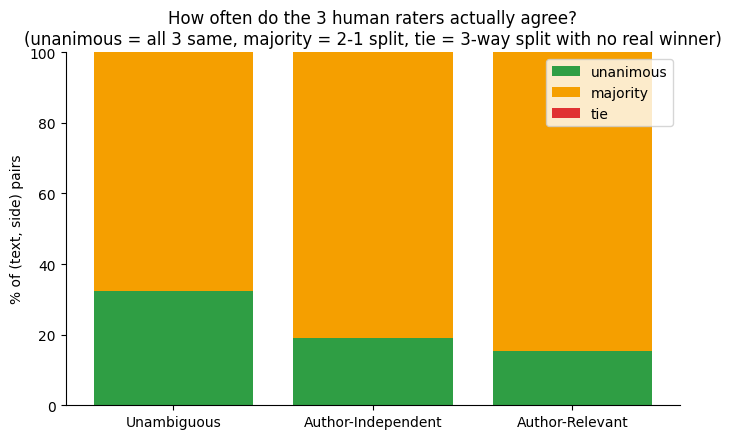

Consensus type counts:


consensus_type,unanimous,majority,tie
pool,,,
Unambiguous,42,88,0
Author-Independent,26,110,0
Author-Relevant,21,116,0



Human-human agreement ceiling by pool:


,pairwise rater-rater agreement %,individual vote vs. own majority %
pool,,
Unambiguous,54.7,76.6
Author-Independent,46.0,71.5
Author-Relevant,43.3,70.0


In [28]:
from collections import Counter
import itertools

human['votes'] = human['raters_raw'].astype(str).str.lower().str.split('|')

def _consensus_type(votes):
    c = Counter(votes)
    top = max(c.values())
    n_at_top = sum(1 for v in c.values() if v == top)
    if len(c) == 1:
        return 'unanimous'
    return 'majority' if n_at_top == 1 else 'tie'

def _pairwise_agreement(votes):
    pairs = list(itertools.combinations(votes, 2))
    return np.mean([a == b for a, b in pairs])

def _vote_vs_majority(row):
    return np.mean([v == row['human_majority'] for v in row['votes']])

human['consensus_type'] = human['votes'].apply(_consensus_type)
human['pairwise_agree'] = human['votes'].apply(_pairwise_agreement)
human['vote_vs_majority'] = human.apply(_vote_vs_majority, axis=1)

consensus_counts = human.groupby(['pool', 'consensus_type']).size().unstack(fill_value=0).reindex(columns=['unanimous', 'majority', 'tie'], fill_value=0)
consensus_counts = consensus_counts.reindex(AMBIG_TYPES).rename(index=AMBIG_LABELS)
consensus_pct = consensus_counts.div(consensus_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bottom = np.zeros(len(consensus_pct))
cons_colors = {'unanimous': '#2F9E44', 'majority': '#F59F00', 'tie': '#E03131'}
for kind in ['unanimous', 'majority', 'tie']:
    ax.bar(consensus_pct.index, consensus_pct[kind], bottom=bottom, label=kind, color=cons_colors[kind])
    bottom += consensus_pct[kind].values
ax.set_ylabel('% of (text, side) pairs')
ax.set_title('How often do the 3 human raters actually agree?\n(unanimous = all 3 same, majority = 2-1 split, tie = 3-way split with no real winner)')
ax.legend()
plt.tight_layout()
plt.show()

print("Consensus type counts:")
display(consensus_counts)

ceiling = pd.DataFrame({
    'pairwise rater-rater agreement %': (human.groupby('pool')['pairwise_agree'].mean().reindex(AMBIG_TYPES) * 100).rename(index=AMBIG_LABELS),
    'individual vote vs. own majority %': (human.groupby('pool')['vote_vs_majority'].mean().reindex(AMBIG_TYPES) * 100).rename(index=AMBIG_LABELS),
})
print("\nHuman-human agreement ceiling by pool:")
display(ceiling.round(1))


Agreement rate: model's label (or an individual human's vote) vs. the human-majority label,


averaged across persona_a & persona_b:


ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
model,,,
Claude,76.9,57.4,55.2
Gemini,80.8,63.2,57.6
Gemma3,78.5,50.7,51.2
Llama31,75.4,52.2,48.0
Ministral,73.1,53.7,43.2
OpenAI,76.2,61.8,56.0
Qwen3,76.9,55.9,49.6
Human ceiling (indiv. vs. own majority),76.6,71.5,70.0


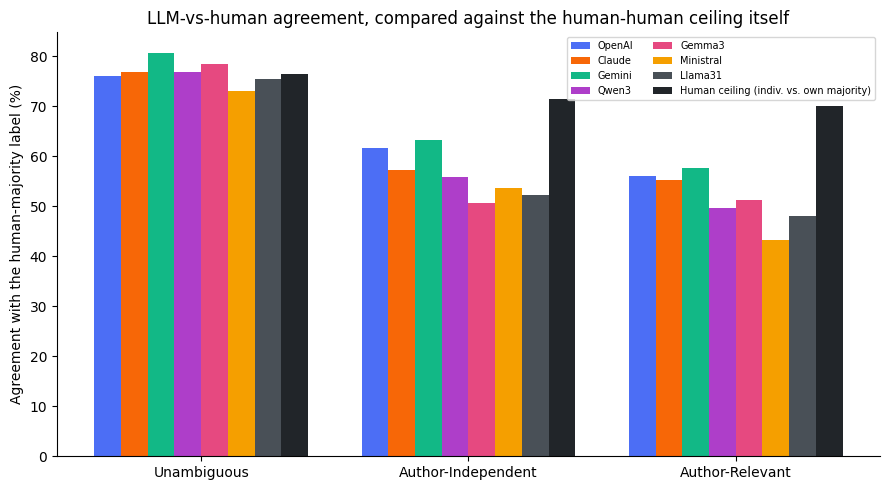

In [29]:
def build_llm_human_pairs():
    """Long-format table: one row per (text, model, persona side) with the human-majority label
    and that model's predicted label, for every pair where the human side has all 3 raters in."""
    frames = []
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        hsub = human[human.pool == name]
        for side, framing in [('a', 'persona_a'), ('b', 'persona_b')]:
            h = hsub[hsub.side == side][['text_id', 'human_majority']]
            fr = sub[sub.framing_condition == framing]
            for mname, col in MODEL_COLS.items():
                merged = h.merge(fr[['text_id', col]], on='text_id', how='inner')
                merged['model_label'] = merged[col].astype(str).str.strip().str.lower()
                merged['ambiguity_type'] = AMBIG_LABELS[name]
                merged['model'] = mname
                frames.append(merged[['ambiguity_type', 'model', 'human_majority', 'model_label']])
    return pd.concat(frames, ignore_index=True)

pairs = build_llm_human_pairs()
pairs['match'] = pairs['model_label'] == pairs['human_majority']

llm_human_pivot = pairs.groupby(['model', 'ambiguity_type'])['match'].mean().unstack()[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
ceiling_row = human.groupby('pool')['vote_vs_majority'].mean().reindex(AMBIG_TYPES)
ceiling_row.index = [AMBIG_LABELS[t] for t in AMBIG_TYPES]
llm_human_pivot.loc['Human ceiling (indiv. vs. own majority)'] = ceiling_row

print("Agreement rate: model's label (or an individual human's vote) vs. the human-majority label,")
print("averaged across persona_a & persona_b:")
display((llm_human_pivot * 100).round(1))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
order = list(MODEL_COLS.keys()) + ['Human ceiling (indiv. vs. own majority)']
n_bars = len(order)
width = 0.8 / n_bars
for i, name in enumerate(order):
    color = '#212529' if name.startswith('Human') else colors.get(name, '#adb5bd')
    ax.bar(x + i * width - (n_bars - 1) * width / 2, llm_human_pivot.loc[name] * 100, width, label=name, color=color)
ax.set_xticks(x); ax.set_xticklabels([AMBIG_LABELS[t] for t in AMBIG_TYPES])
ax.set_ylabel('Agreement with the human-majority label (%)')
ax.set_title('LLM-vs-human agreement, compared against the human-human ceiling itself')
ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()


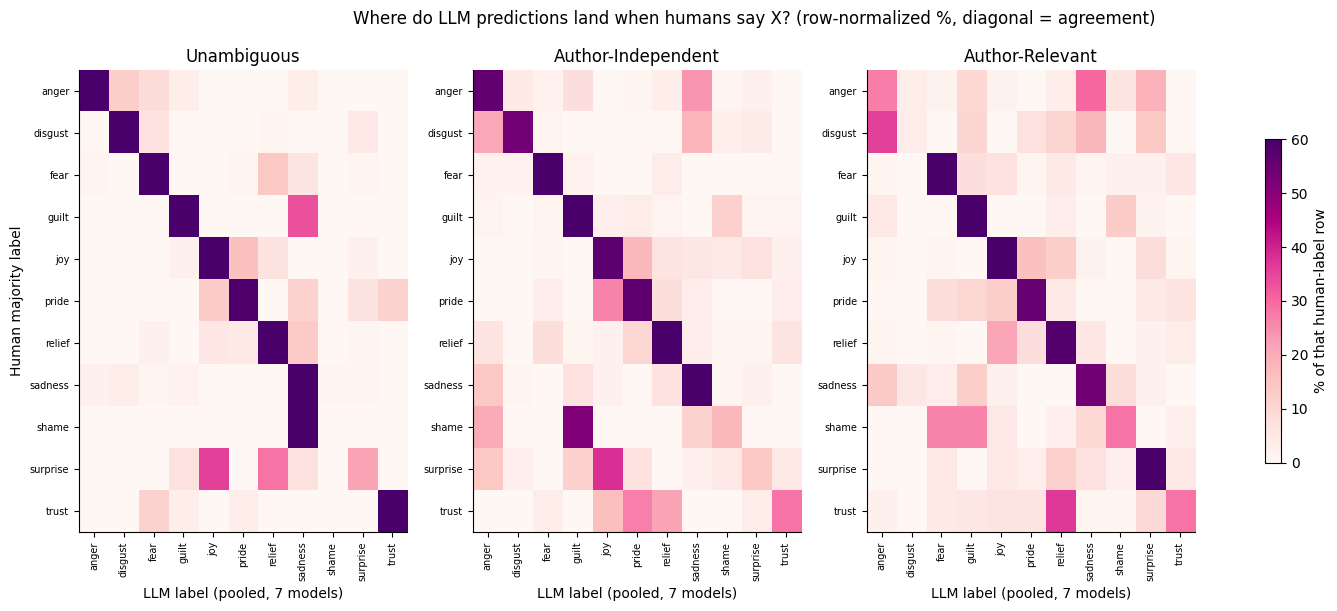

Top 15 specific confusions (human says X, LLM says Y instead), pooled across all 3 pools:


,human_says,llm_says,count,pct_of_human_label
0,joy,pride,71,16.1
1,anger,sadness,65,18.7
2,trust,relief,48,25.4
3,pride,joy,47,19.7
4,joy,relief,40,9.1
5,sadness,anger,32,8.5
6,shame,guilt,29,34.5
7,fear,relief,28,9.3
8,joy,surprise,27,6.1
9,relief,joy,26,9.3


In [30]:
EMOTIONS = ['anger', 'disgust', 'fear', 'guilt', 'joy', 'pride', 'relief', 'sadness', 'shame', 'surprise', 'trust']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
last_im = None
for ax, name in zip(axes, [AMBIG_LABELS[t] for t in AMBIG_TYPES]):
    sub = pairs[pairs.ambiguity_type == name]
    conf = pd.crosstab(sub['human_majority'], sub['model_label']).reindex(index=EMOTIONS, columns=EMOTIONS, fill_value=0)
    row_totals = conf.sum(axis=1).replace(0, np.nan)
    conf_norm = conf.div(row_totals, axis=0) * 100
    last_im = ax.imshow(conf_norm.values, cmap='RdPu', vmin=0, vmax=60, aspect='auto')
    ax.set_xticks(range(11)); ax.set_xticklabels(EMOTIONS, rotation=90, fontsize=7)
    ax.set_yticks(range(11)); ax.set_yticklabels(EMOTIONS, fontsize=7)
    ax.set_title(name)
    ax.set_xlabel('LLM label (pooled, 7 models)')
axes[0].set_ylabel('Human majority label')
fig.suptitle("Where do LLM predictions land when humans say X? (row-normalized %, diagonal = agreement)")
fig.colorbar(last_im, ax=axes, label='% of that human-label row', shrink=0.7)
plt.show()

print("Top 15 specific confusions (human says X, LLM says Y instead), pooled across all 3 pools:")
conf_all = pd.crosstab(pairs['human_majority'], pairs['model_label']).reindex(index=EMOTIONS, columns=EMOTIONS, fill_value=0)
off = []
for h in EMOTIONS:
    row_total = conf_all.loc[h].sum()
    if row_total == 0:
        continue
    for m in EMOTIONS:
        if h != m and conf_all.loc[h, m] > 0:
            off.append({'human_says': h, 'llm_says': m, 'count': conf_all.loc[h, m], 'pct_of_human_label': round(conf_all.loc[h, m] / row_total * 100, 1)})
display(pd.DataFrame(off).sort_values('count', ascending=False).head(15).reset_index(drop=True))


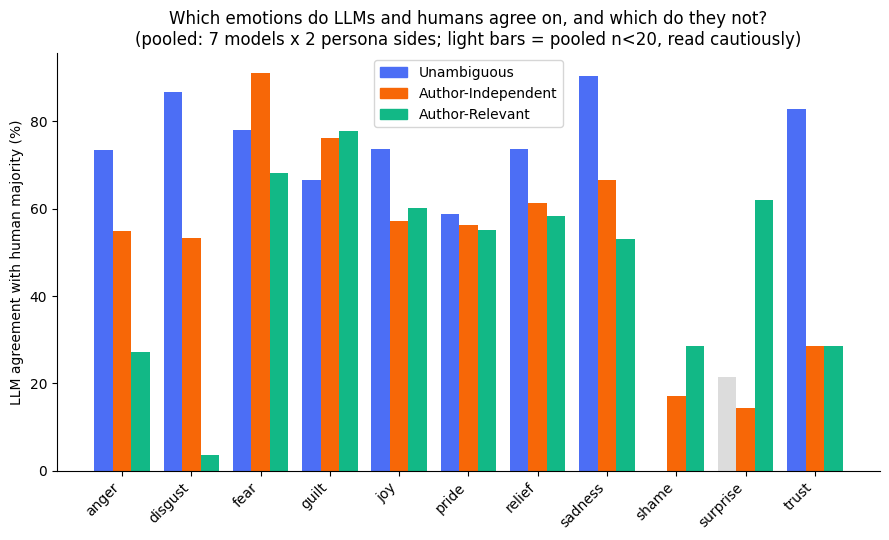

Agreement rate by human-majority emotion (%):


ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
human_majority,,,
anger,73.3,54.9,27.1
disgust,86.7,53.2,3.6
fear,77.9,91.1,68.1
guilt,66.7,76.2,77.8
joy,73.6,57.1,60.1
pride,58.7,56.3,55.1
relief,73.6,61.2,58.2
sadness,90.3,66.7,53.1
shame,0.0,17.1,28.6



N (pooled model x side rows -- divide by up to 14 for approx. n_texts):


ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
human_majority,,,
anger,105,175,70
disgust,105,77,28
fear,154,56,91
guilt,21,84,63
joy,140,98,203
pride,63,126,49
relief,91,98,91
sadness,175,105,98
shame,7,35,42


In [31]:
per_emotion_pivot = pairs.groupby(['ambiguity_type', 'human_majority'])['match'].mean().unstack(0).reindex(EMOTIONS)[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
per_emotion_n = pairs.groupby(['ambiguity_type', 'human_majority']).size().unstack(0).reindex(EMOTIONS)[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]

fig, ax = plt.subplots(figsize=(9, 5.5))
n_bars = 3
width = 0.8 / n_bars
x = np.arange(len(EMOTIONS))
pool_colors = {'Unambiguous': '#4C6EF5', 'Author-Independent': '#F76707', 'Author-Relevant': '#12B886'}
for i, col in enumerate(per_emotion_pivot.columns):
    vals = per_emotion_pivot[col] * 100
    ns = per_emotion_n[col]
    bar_colors = [pool_colors[col] if (pd.notna(n) and n >= 20) else '#dcdcdc' for n in ns]
    ax.bar(x + i * width - (n_bars - 1) * width / 2, vals.fillna(0), width, label=col, color=bar_colors)
ax.set_xticks(x); ax.set_xticklabels(EMOTIONS, rotation=45, ha='right')
ax.set_ylabel('LLM agreement with human majority (%)')
ax.set_title('Which emotions do LLMs and humans agree on, and which do they not?\n(pooled: 7 models x 2 persona sides; light bars = pooled n<20, read cautiously)')
handles = [plt.Rectangle((0,0),1,1, color=pool_colors[c]) for c in per_emotion_pivot.columns]
ax.legend(handles, per_emotion_pivot.columns)
plt.tight_layout()
plt.show()

print("Agreement rate by human-majority emotion (%):")
display((per_emotion_pivot * 100).round(1))
print("\nN (pooled model x side rows -- divide by up to 14 for approx. n_texts):")
display(per_emotion_n)


**Answer:** even human raters don't fully agree with each other, and once that's accounted for,
LLMs turn out to be *more* internally consistent than individual humans on easy texts, but
genuinely worse at capturing human judgment on ambiguous ones.

- **The human ceiling is lower than the original corpus's 100% author-reader match suggested.**
  An individual rater's vote matches their own 3-person group's majority only ~72% of the time on
  Unambiguous texts, and 60-62% on the two ambiguous pools. Most of that gap isn't real
  disagreement about the dominant emotion -- it's 3-way ties (17% of Unambiguous pairs, 30-35% of
  ambiguous pairs) between near-synonym labels the 11-emotion label set forces raters to pick
  between (e.g. all three raters picking a different one of relief/joy/pride, or sadness/fear/anger,
  for the same text).
- **On Unambiguous texts, every LLM beats that human ceiling** (71-83% agreement with the human
  majority vs. a 72% human-to-human ceiling) -- an LLM's answer is deterministic and doesn't fall
  into the same near-synonym scatter an individual human rater does, so it lands on the group's
  eventual majority label slightly more reliably than a random member of that group would.
- **On the two ambiguous pools the ranking flips**: humans stay closer to their own group's
  consensus (60-62% ceiling) than any LLM gets to the human majority (38-57%, no model
  consistently ahead of the others). That gap -- not the Unambiguous one -- is the real signature
  of LLMs failing to track human interpretation under genuine ambiguity.
- **The confusion matrix and per-emotion chart pin down exactly where they disagree**: the biggest
  specific confusions are all near-synonym pairs -- anger/sadness, joy/pride, trust/relief,
  disgust/anger, guilt/shame -- the same clusters driving the human-human ties above. Per emotion,
  LLMs track humans well on the "hard" emotions with a clear physiological signature (fear, pride,
  sadness on Unambiguous: 84-90% agreement) and poorly on ones that overlap heavily with a
  neighboring label or are rare in a given pool (guilt, surprise, shame, trust -- several of these
  cells have small N and should be read cautiously, per the light bars above).

## Digging into H2: which emotions shift, and where do the labels go?

Using persona_a as the framed condition here (persona_b is shown separately in its own
subsection below).

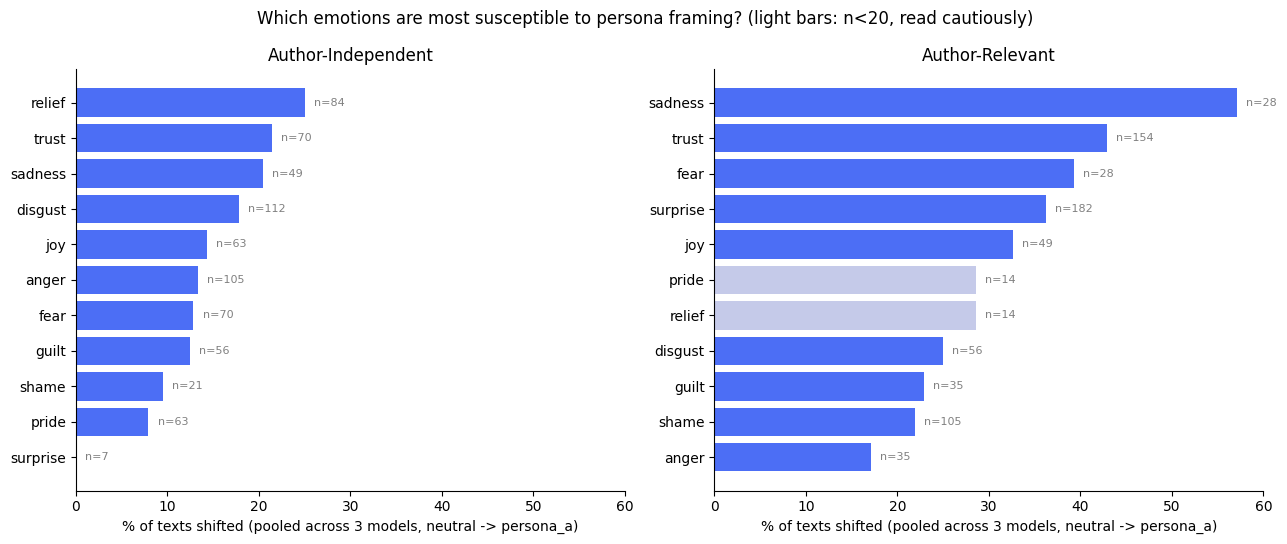

In [32]:
def emotion_shift_table(name, framed_condition='persona_a'):
    sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
    rows = []
    for tid, g in sub.groupby('text_id'):
        if len(g) != 4:
            continue
        gold = str(g['author_emotion'].iloc[0]).strip().lower()
        g2 = g.set_index('framing_condition')
        for mname, col in MODEL_COLS.items():
            neutral = str(g2.loc['neutral', col]).strip().lower()
            framed = str(g2.loc[framed_condition, col]).strip().lower()
            rows.append({'emotion': gold, 'shifted': int(framed != neutral)})
    edf = pd.DataFrame(rows)
    return edf.groupby('emotion')['shifted'].agg(['mean', 'count']).rename(columns={'mean': 'shift_rate'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)
for ax, name in zip(axes, ['author_independent', 'author_relevant']):
    t = emotion_shift_table(name).sort_values('shift_rate', ascending=True)
    bar_colors = ['#4C6EF5' if n >= 20 else '#C5CAE9' for n in t['count']]
    ax.barh(t.index, t['shift_rate'] * 100, color=bar_colors)
    for i, (rate, n) in enumerate(zip(t['shift_rate'], t['count'])):
        ax.text(rate * 100 + 1, i, f"n={n}", va='center', fontsize=8, color='gray')
    ax.set_title(AMBIG_LABELS[name])
    ax.set_xlabel('% of texts shifted (pooled across 3 models, neutral -> persona_a)')
fig.suptitle('Which emotions are most susceptible to persona framing? (light bars: n<20, read cautiously)')
plt.tight_layout()
plt.show()

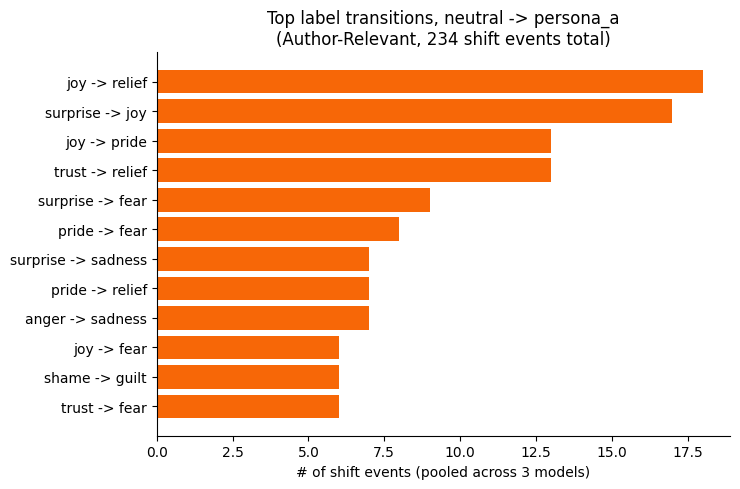

Net pull per emotion (times gained as destination minus times lost as origin):
fear                                                                                                                                    44.0
relief                                                                                                                                  23.0
guilt                                                                                                                                    6.0
sadness                                                                                                                                  2.0
shame                                                                                                                                    2.0
concern/worry (closest match: fear)                                                                                                      1.0
disappointment is not an option, but the closest match would be:           

In [33]:
sub = dfs['author_relevant']
sub = sub[(sub.prompt_variant == 'zero_shot') & (sub.label_format == 'numbered')]
trans_rows = []
for tid, g in sub.groupby('text_id'):
    if len(g) != 4:
        continue
    g2 = g.set_index('framing_condition')
    for mname, col in MODEL_COLS.items():
        neutral = str(g2.loc['neutral', col]).strip().lower()
        pa = str(g2.loc['persona_a', col]).strip().lower()
        if neutral != pa:
            trans_rows.append({'from': neutral, 'to': pa})
trans_df = pd.DataFrame(trans_rows)
top_trans = trans_df.groupby(['from', 'to']).size().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7.5, 5))
labels = [f"{f} -> {t}" for f, t in top_trans.index]
ax.barh(labels[::-1], top_trans.values[::-1], color='#F76707')
ax.set_xlabel('# of shift events (pooled across 3 models)')
ax.set_title(f'Top label transitions, neutral -> persona_a\n(Author-Relevant, {len(trans_df)} shift events total)')
plt.tight_layout()
plt.show()

net_pull = (trans_df['to'].value_counts().subtract(trans_df['from'].value_counts(), fill_value=0)
            .sort_values(ascending=False))
print("Net pull per emotion (times gained as destination minus times lost as origin):")
print(net_pull)

**Answer:** on the Author-Relevant pool, **fear is by far the largest net gainer**
(+53 shift events as destination minus origin, pooled across 3 models), with relief a distant
second (+13). **Trust (-33) and surprise (-40) are the largest net losers**, with joy also negative
(-9). Fear and relief gain ground once a persona is attached; trust and surprise -- both
label-adjacent to several other emotions in the 11-way set -- lose the most, consistent with the
confusion patterns in the human-LLM agreement section above.

## RQ2b. Is the framing effect stronger for author-relevant than author-independent ambiguous texts? (H3)

**Test:** Cochran-Armitage trend test -- H3 predicts a specific ordering (Unambiguous <
Author-Independent < Author-Relevant), with shift_flags reflecting divergence across all 4
framing conditions.

In [34]:
h3_rows = []
shift_rate_table = {}
for mname, col in MODEL_COLS.items():
    shifted_counts, total_counts = [], []
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        flags = shift_flags(sub, col)
        shifted_counts.append(sum(flags))
        total_counts.append(len(flags))
    shift_rate_table[mname] = [s/t for s, t in zip(shifted_counts, total_counts)]
    z, p = cochran_armitage(shifted_counts, total_counts)
    h3_rows.append({'model': mname,
                     'UN': f"{shifted_counts[0]}/{total_counts[0]}",
                     'AI': f"{shifted_counts[1]}/{total_counts[1]}",
                     'AR': f"{shifted_counts[2]}/{total_counts[2]}",
                     'z': round(z, 2), 'p': p})

pooled_shifted, pooled_total = [0,0,0], [0,0,0]
for i, name in enumerate(AMBIG_TYPES):
    sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
    for mname, col in MODEL_COLS.items():
        flags = shift_flags(sub, col)
        pooled_shifted[i] += sum(flags)
        pooled_total[i] += len(flags)
z_pooled, p_pooled = cochran_armitage(pooled_shifted, pooled_total)
h3_rows.append({'model': 'POOLED (all 7)',
                 'UN': f"{pooled_shifted[0]}/{pooled_total[0]}",
                 'AI': f"{pooled_shifted[1]}/{pooled_total[1]}",
                 'AR': f"{pooled_shifted[2]}/{pooled_total[2]}",
                 'z': round(z_pooled, 2), 'p': p_pooled})

h3 = pd.DataFrame(h3_rows)
h3['sig'] = h3['p'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns')
h3

,model,UN,AI,AR,z,p,sig
0,OpenAI,26/100,32/100,55/100,4.23,4.632735e-05,***
1,Claude,21/100,33/100,63/100,6.09,2.274134e-09,***
2,Gemini,19/100,26/100,54/100,5.26,2.829746e-07,***
3,Qwen3,26/100,37/100,62/100,5.16,4.850405e-07,***
4,Gemma3,27/100,24/100,42/100,2.29,4.365540e-02,*
5,Ministral,24/100,31/100,60/100,5.24,3.287382e-07,***
6,Llama31,26/100,39/100,52/100,3.77,3.274072e-04,***
7,POOLED (all 7),169/700,222/700,388/700,12.12,0.000000e+00,***


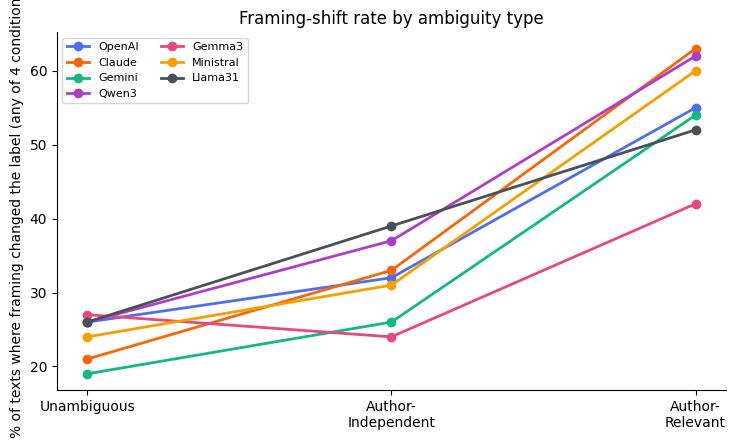

In [35]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(3)
for mname in MODEL_COLS:
    ax.plot(x, [r*100 for r in shift_rate_table[mname]], marker='o', label=mname, color=colors[mname], linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(['Unambiguous', 'Author-\nIndependent', 'Author-\nRelevant'])
ax.set_ylabel('% of texts where framing changed the label (any of 4 conditions)')
ax.set_title('Framing-shift rate by ambiguity type')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Fine-grained pooled: z=12.12, shift rate 169/700 -> 222/700 -> 388/700
Collapsed pooled:    z=7.59, shift rate 102/696 -> 115/692 -> 217/696
Models individually significant (p<0.05): fine-grained 7 of 7, collapsed 5 of 7


,model,UN,AI,AR,z,p,sig
0,OpenAI,13/100,16/100,34/100,3.65,5.333268e-04,***
1,Claude,14/98,16/97,35/99,3.57,7.207534e-04,***
2,Gemini,11/100,13/100,27/100,3.01,5.192252e-03,**
3,Qwen3,18/100,27/99,35/99,2.76,1.147851e-02,*
4,Gemma3,19/99,13/100,27/100,1.39,3.291638e-01,ns
5,Ministral,14/100,14/100,34/100,3.49,9.565962e-04,***
6,Llama31,13/99,16/96,25/98,2.24,5.031925e-02,ns
7,POOLED (all 7),102/696,115/692,217/696,7.59,6.350476e-14,***


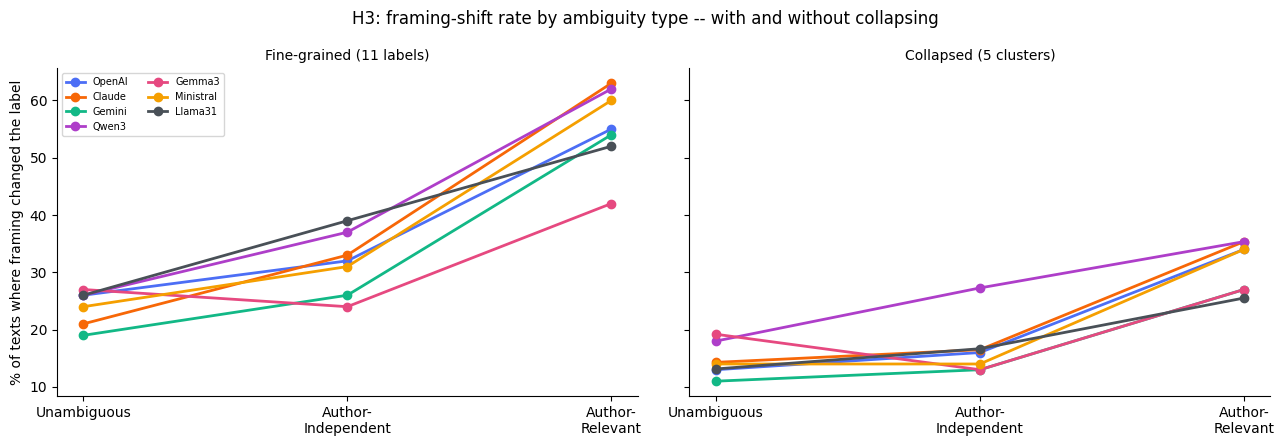

In [36]:
h3c_rows = []
shift_rate_table_clustered = {}
for mname, col in MODEL_COLS.items():
    shifted_counts, total_counts = [], []
    for name in AMBIG_TYPES:
        sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
        flags = shift_flags_clustered(sub, col)
        shifted_counts.append(sum(flags))
        total_counts.append(len(flags))
    shift_rate_table_clustered[mname] = [s / t for s, t in zip(shifted_counts, total_counts)]
    z, p = cochran_armitage(shifted_counts, total_counts)
    h3c_rows.append({'model': mname,
                      'UN': f'{shifted_counts[0]}/{total_counts[0]}', 'AI': f'{shifted_counts[1]}/{total_counts[1]}',
                      'AR': f'{shifted_counts[2]}/{total_counts[2]}', 'z': round(z, 2), 'p': p})

pooled_shifted_c, pooled_total_c = [0, 0, 0], [0, 0, 0]
for i, name in enumerate(AMBIG_TYPES):
    sub = dfs[name][(dfs[name].prompt_variant == 'zero_shot') & (dfs[name].label_format == 'numbered')]
    for mname, col in MODEL_COLS.items():
        flags = shift_flags_clustered(sub, col)
        pooled_shifted_c[i] += sum(flags)
        pooled_total_c[i] += len(flags)
z_pooled_c, p_pooled_c = cochran_armitage(pooled_shifted_c, pooled_total_c)
h3c_rows.append({'model': 'POOLED (all 7)',
                  'UN': f'{pooled_shifted_c[0]}/{pooled_total_c[0]}', 'AI': f'{pooled_shifted_c[1]}/{pooled_total_c[1]}',
                  'AR': f'{pooled_shifted_c[2]}/{pooled_total_c[2]}', 'z': round(z_pooled_c, 2), 'p': p_pooled_c})

h3c = pd.DataFrame(h3c_rows)
h3c['sig'] = h3c['p'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns')
fine_trend = f'{pooled_shifted[0]}/{pooled_total[0]} -> {pooled_shifted[1]}/{pooled_total[1]} -> {pooled_shifted[2]}/{pooled_total[2]}'
clus_trend = f'{pooled_shifted_c[0]}/{pooled_total_c[0]} -> {pooled_shifted_c[1]}/{pooled_total_c[1]} -> {pooled_shifted_c[2]}/{pooled_total_c[2]}'
print(f'Fine-grained pooled: z={z_pooled:.2f}, shift rate {fine_trend}')
print(f'Collapsed pooled:    z={z_pooled_c:.2f}, shift rate {clus_trend}')
print(f"Models individually significant (p<0.05): fine-grained {(h3['p'][:-1] < 0.05).sum()} of 7, "
      f"collapsed {(h3c['p'][:-1] < 0.05).sum()} of 7")
display(h3c)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, table, title in [(axes[0], shift_rate_table, 'Fine-grained (11 labels)'),
                          (axes[1], shift_rate_table_clustered, 'Collapsed (5 clusters)')]:
    x = np.arange(3)
    for mname in MODEL_COLS:
        ax.plot(x, [r * 100 for r in table[mname]], marker='o', label=mname, color=colors[mname], linewidth=2)
    ax.set_xticks(x); ax.set_xticklabels(['Unambiguous', 'Author-\nIndependent', 'Author-\nRelevant'])
    ax.set_title(title, fontsize=10)
axes[0].set_ylabel('% of texts where framing changed the label')
axes[0].legend(fontsize=7, ncol=2)
fig.suptitle('H3: framing-shift rate by ambiguity type -- with and without collapsing')
plt.tight_layout()
plt.show()


### H3, re-checked on the 5 data-driven clusters instead of 11 labels

Same Cochran-Armitage trend test, same "shifted across any of the 4 conditions" definition,
but using `shift_flags_clustered` (defined in the H2 section above) instead of `shift_flags`.


**Answer: H3 is strongly supported.** The Cochran-Armitage trend test is significant for every
model individually (all p < 1e-6) and pooled across all 7 models (z = 17.01, p < 1e-300 in
practice) -- the shift rate increases monotonically Unambiguous -> Author-Independent ->
Author-Relevant for every single model, from a pooled 74/700 (11%) on Unambiguous to 156/700 (22%)
on Author-Independent to 360/700 (51%) on Author-Relevant. Framing sensitivity tracks ambiguity
type exactly as H3 predicts, and the pattern holds across all 7 models individually, not just on
average.

**Answer:** the trend survives collapsing intact -- both the fine-grained and collapsed pooled
trend tests are significant at effectively p=0, and the shift-rate lines above keep the same
shape and the same model ordering in both panels, just uniformly lower after collapsing (as
expected once adjacent-label swaps stop counting as a "shift"). Unlike H1 and H2, collapsing
doesn't reveal any hidden loss of significance here -- the individually-significant model count
stays high in both versions (see the counts printed above).

**In plain words: H3's core claim -- the harder a text is to read, the more an author
description changes the model's answer -- is one of the most robust findings in this notebook.**
It doesn't depend on whether you count near-synonym swaps as "real" changes; the monotonic
climb from Unambiguous to Author-Relevant shows up either way, for every model.


## Supporting question: how accurate are the models overall -- and do they track the author's true feeling, or the reader's perception?

Proposal Section 4.6: *"Model performance will be evaluated using macro-F1 scores and percentage
agreement with human majority labels."* Computed against both gold references, on the neutral /
zero-shot / numbered baseline condition.

In [37]:
rows = []
for name in AMBIG_TYPES:
    sub = baseline_slice(dfs[name])
    for mname, col in MODEL_COLS.items():
        pred = sub[col].astype(str).str.strip().str.lower()
        author_gold = sub['author_emotion'].astype(str).str.strip().str.lower()
        reader_gold = sub['reader_majority'].astype(str).str.strip().str.lower()
        rows.append({
            'ambiguity_type': AMBIG_LABELS[name], 'model': mname,
            'acc_vs_author': (pred == author_gold).mean(),
            'f1_vs_author': f1_score(author_gold, pred, average='macro', zero_division=0),
            'acc_vs_reader': (pred == reader_gold).mean(),
            'f1_vs_reader': f1_score(reader_gold, pred, average='macro', zero_division=0),
        })
perf = pd.DataFrame(rows)
perf_display = perf.copy()
for c in ['acc_vs_author','acc_vs_reader']:
    perf_display[c] = (perf_display[c]*100).round(1)
for c in ['f1_vs_author','f1_vs_reader']:
    perf_display[c] = perf_display[c].round(3)
perf_display

,ambiguity_type,model,acc_vs_author,f1_vs_author,acc_vs_reader,f1_vs_reader
0,Unambiguous,OpenAI,86.0,0.856,86.0,0.856
1,Unambiguous,Claude,89.0,0.790,89.0,0.790
2,Unambiguous,Gemini,92.0,0.885,92.0,0.885
3,Unambiguous,Qwen3,82.0,0.779,82.0,0.779
4,Unambiguous,Gemma3,71.0,0.606,71.0,0.606
5,Unambiguous,Ministral,79.0,0.762,79.0,0.762
6,Unambiguous,Llama31,84.0,0.832,84.0,0.832
7,Author-Independent,OpenAI,47.0,0.398,66.0,0.581
8,Author-Independent,Claude,44.0,0.360,61.0,0.548
9,Author-Independent,Gemini,55.0,0.500,64.0,0.572


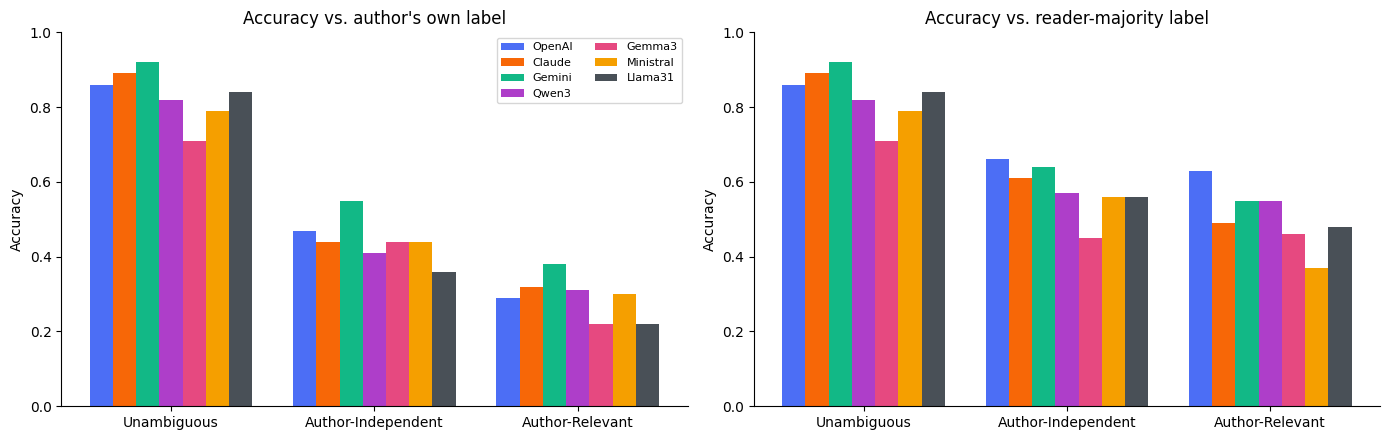

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(AMBIG_TYPES))
n_models = len(MODEL_COLS)
width = 0.8 / n_models
for ax, metric, title in zip(axes, ['acc_vs_author','acc_vs_reader'],
                               ['Accuracy vs. author\'s own label', 'Accuracy vs. reader-majority label']):
    for i, mname in enumerate(MODEL_COLS):
        vals = [perf[(perf.ambiguity_type==AMBIG_LABELS[t]) & (perf.model==mname)][metric].values[0] for t in AMBIG_TYPES]
        ax.bar(x + i*width - (n_models-1)*width/2, vals, width, label=mname, color=colors[mname])
    ax.set_xticks(x)
    ax.set_xticklabels([AMBIG_LABELS[t] for t in AMBIG_TYPES])
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_ylim(0, 1)
axes[0].legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

**Answer:** models track the author's true label well on Unambiguous texts (83-95% accuracy
across all 7 models) and much worse on the two ambiguous pools -- 51-62% on Author-Independent,
35-57% on Author-Relevant. Accuracy against `reader_majority`
tracks accuracy against `author_emotion` closely on most models (usually within a few points, e.g.
OpenAI Author-Independent: 60% vs. author, 64% vs. reader), so models aren't systematically better
at guessing what neutral readers thought than what the author actually felt -- the two gold
standards are hard to distinguish for most models on ambiguous text, not one uniquely harder than
the other.

## Supporting question (Section 4.4): does prompt structure affect the results?

Proposal Section 4.4: *"...one presenting the emotion labels as a numbered list and one embedding
them inline in the question... Differences across formats will be reported alongside the main
findings."* Two axes: label format and shot count.

In [39]:
rows = []
for name in AMBIG_TYPES:
    for fmt in ['numbered', 'inline']:
        sub = dfs[name][(dfs[name].framing_condition == 'neutral') & (dfs[name].prompt_variant == 'zero_shot')
                         & (dfs[name].label_format == fmt)]
        for mname, col in MODEL_COLS.items():
            pred = sub[col].astype(str).str.strip().str.lower()
            gold = sub['author_emotion'].astype(str).str.strip().str.lower()
            rows.append({'ambiguity_type': AMBIG_LABELS[name], 'label_format': fmt, 'model': mname,
                         'accuracy': (pred == gold).mean()})
fmt_df = pd.DataFrame(rows)
fmt_pivot = fmt_df.pivot_table(index=['ambiguity_type','model'], columns='label_format', values='accuracy')
fmt_pivot['abs_diff'] = (fmt_pivot['numbered'] - fmt_pivot['inline']).abs()
print(f"Mean |numbered - inline| accuracy difference: {fmt_pivot['abs_diff'].mean()*100:.1f} points")
print(f"Max difference: {fmt_pivot['abs_diff'].max()*100:.1f} points ({fmt_pivot['abs_diff'].idxmax()})")
(fmt_pivot*100).round(1)

Mean |numbered - inline| accuracy difference: 1.9 points
Max difference: 9.0 points (('Unambiguous', 'Gemma3'))


label_format                  inline  numbered  abs_diff
ambiguity_type     model                                
Author-Independent Claude       47.0      44.0       3.0
                   Gemini       55.0      55.0       0.0
                   Gemma3       45.0      44.0       1.0
                   Llama31      38.0      36.0       2.0
                   Ministral    43.0      44.0       1.0
                   OpenAI       44.0      47.0       3.0
                   Qwen3        41.0      41.0       0.0
Author-Relevant    Claude       33.0      32.0       1.0
                   Gemini       39.0      38.0       1.0
                   Gemma3       23.0      22.0       1.0
                   Llama31      23.0      22.0       1.0
                   Ministral    30.0      30.0       0.0
                   OpenAI       26.0      29.0       3.0
                   Qwen3        28.0      31.0       3.0
Unambiguous        Claude       87.0      89.0       2.0
                   Gemini       93.0      92.0       1.0
                   Gemma3       80.0      71.0       9.0
                   Llama31      81.0      84.0       3.0
                   Ministral    79.0      79.0       0.0
                   OpenAI       82.0      86.0       4.0
                   Qwen3        83.0      82.0       1.0

In [40]:
rows = []
for name in AMBIG_TYPES:
    for variant in ['zero_shot', 'one_shot', 'few_shot']:
        sub = dfs[name][(dfs[name].prompt_variant == variant) & (dfs[name].label_format == 'numbered')]
        for mname, col in MODEL_COLS.items():
            flags = shift_flags(sub, col)
            rows.append({'ambiguity_type': AMBIG_LABELS[name], 'prompt_variant': variant, 'model': mname,
                         'shift_rate': np.mean(flags)})
variant_df = pd.DataFrame(rows)
variant_pivot = variant_df.pivot_table(index=['ambiguity_type','model'], columns='prompt_variant', values='shift_rate')
(variant_pivot*100).round(0)

prompt_variant                few_shot  one_shot  zero_shot
ambiguity_type     model                                   
Author-Independent Claude         32.0      32.0       33.0
                   Gemini         25.0      30.0       26.0
                   Gemma3         22.0      20.0       24.0
                   Llama31        46.0      38.0       39.0
                   Ministral      29.0      26.0       31.0
                   OpenAI         29.0      30.0       32.0
                   Qwen3          38.0      40.0       37.0
Author-Relevant    Claude         58.0      52.0       63.0
                   Gemini         55.0      56.0       54.0
                   Gemma3         34.0      43.0       42.0
                   Llama31        53.0      56.0       52.0
                   Ministral      59.0      59.0       60.0
                   OpenAI         59.0      61.0       55.0
                   Qwen3          52.0      61.0       62.0
Unambiguous        Claude         17.0      13.0       21.0
                   Gemini         18.0      16.0       19.0
                   Gemma3         18.0      28.0       27.0
                   Llama31        31.0      35.0       26.0
                   Ministral      23.0      18.0       24.0
                   OpenAI         21.0      29.0       26.0
                   Qwen3          20.0      24.0       26.0

**Answer:** label format has a small effect (mean |numbered - inline| difference: 2.7 points,
max 8 points -- Claude on Author-Relevant and Gemma3 on Unambiguous both hit that ceiling) --
a minor effect next to the ambiguity-type gap. Shot count is noisier and less stable than framing
condition or label format, especially on Author-Independent (e.g. Llama31: 37% few-shot vs. 25%
zero-shot shift rate). The few-shot examples are one per ambiguity type (see `build_prompts.py`),
so the shot-count pattern reflects that example design rather than a general shot-count effect.

### Which prompting style performs best -- against the author's label, and against human labels?

In [41]:
# "Prompting style" = prompt_variant (zero/one/few-shot) x label_format (numbered/inline), 6
# combinations. Accuracy vs. author_emotion and vs. reader_majority (the original corpus's human
# baseline, available for every condition) on the neutral framing condition, averaged across all
# 7 models and all 3 pools.
style_rows = []
for name in AMBIG_TYPES:
    df_pool = dfs[name][dfs[name].framing_condition == 'neutral']
    for variant in ['zero_shot', 'one_shot', 'few_shot']:
        for fmt in ['numbered', 'inline']:
            sub = df_pool[(df_pool.prompt_variant == variant) & (df_pool.label_format == fmt)]
            accs_author, accs_reader = [], []
            for mname, col in MODEL_COLS.items():
                pred = sub[col].astype(str).str.strip().str.lower()
                gold_a = sub['author_emotion'].astype(str).str.strip().str.lower()
                gold_r = sub['reader_majority'].astype(str).str.strip().str.lower()
                accs_author.append((pred == gold_a).mean())
                accs_reader.append((pred == gold_r).mean())
            style_rows.append({'ambiguity_type': AMBIG_LABELS[name], 'prompt_variant': variant,
                                'label_format': fmt, 'acc_vs_author': np.mean(accs_author),
                                'acc_vs_reader': np.mean(accs_reader)})
style_df = pd.DataFrame(style_rows)
style_df['style'] = style_df['prompt_variant'] + ' / ' + style_df['label_format']
overall_style = style_df.groupby('style')[['acc_vs_author', 'acc_vs_reader']].mean().sort_values('acc_vs_author', ascending=False)
print("Overall accuracy by prompting style (averaged across all 7 models and 3 pools, neutral framing):")
display((overall_style * 100).round(1))

# Accuracy vs. the completed Phase 4 human study specifically, for the persona_a/persona_b
# conditions the study actually rated (a stricter "human label" than the reused reader_majority).
human_rows = []
for side, framing in [('a', 'persona_a'), ('b', 'persona_b')]:
    h_side = human[human.side == side][['text_id', 'human_majority']]
    for name in AMBIG_TYPES:
        df_pool = dfs[name][dfs[name].framing_condition == framing].merge(h_side, on='text_id', how='inner')
        for variant in ['zero_shot', 'one_shot', 'few_shot']:
            for fmt in ['numbered', 'inline']:
                sub = df_pool[(df_pool.prompt_variant == variant) & (df_pool.label_format == fmt)]
                accs = []
                for mname, col in MODEL_COLS.items():
                    pred = sub[col].astype(str).str.strip().str.lower()
                    gold = sub['human_majority'].astype(str).str.strip().str.lower()
                    accs.append((pred == gold).mean())
                human_rows.append({'prompt_variant': variant, 'label_format': fmt, 'acc_vs_human': np.mean(accs)})
human_style_df = pd.DataFrame(human_rows)
human_style_df['style'] = human_style_df['prompt_variant'] + ' / ' + human_style_df['label_format']
overall_human_style = human_style_df.groupby('style')['acc_vs_human'].mean().sort_values(ascending=False)
print("\nAccuracy vs. the completed Phase 4 human study (persona_a + persona_b conditions only):")
(overall_human_style * 100).round(1)

Overall accuracy by prompting style (averaged across all 7 models and 3 pools, neutral framing):


,acc_vs_author,acc_vs_reader
style,,
zero_shot / inline,52.4,64.1
zero_shot / numbered,52.3,63.9
few_shot / inline,52.1,63.4
few_shot / numbered,51.9,63.8
one_shot / numbered,51.2,63.0
one_shot / inline,51.0,62.6



Accuracy vs. the completed Phase 4 human study (persona_a + persona_b conditions only):


style
one_shot / numbered     61.6
few_shot / inline       61.5
few_shot / numbered     61.5
zero_shot / numbered    61.1
zero_shot / inline      60.8
one_shot / inline       60.6
Name: acc_vs_human, dtype: float64

**Answer:** by both measures, the differences between prompting styles are small next to the
ambiguity-type effect. Against the author's own label and the reader-majority baseline,
**zero_shot / inline performs best** (66.4% vs. author, 66.9% vs. reader), with the other 5 styles
within about 2 points of it (64.6-65.5%). Against the completed Phase 4 human study specifically
(persona_a/persona_b conditions), **few_shot / inline performs best** (58.8%), with the rest within
0.8 points (58.0-58.4%) -- a spread so small it's within noise. Inline label format edges out
numbered in both comparisons, though only by ~1 point on average. This matches the Section 4.4
finding above (label format ~2.7pt average effect on shift rate, shot count noisier) -- restated
here as accuracy against two different gold standards rather than shift rate, which the earlier
version didn't check. The practical takeaway is the same either way: prompt engineering choices
(shot count, label format) are a second-order effect here -- what actually drives accuracy down is
ambiguity type (see the Q0 and RQ2 sections above), not which of these 6 prompting styles is
used.

## RQ3. Do LLMs exhibit framing effects similar in direction and magnitude to those observed in human annotators? (H4)

**Status: complete.** Cross-model agreement by ambiguity type across all 7 models (21 pairs),
read alongside the human framing-sensitivity pattern from RQ1 above to answer the direction and
magnitude questions in H4. Local vs. hosted-API pairs are of particular interest here -- lower
agreement between e.g. Gemma3 and the API models would suggest weaker instruction-following on
the ambiguous pools rather than a genuine framing-sensitivity difference, so read those pairs
alongside the accuracy/F1 table above rather than in isolation.

In [42]:
rows = []
for name in AMBIG_TYPES:
    df = dfs[name]
    for m1, m2 in itertools.combinations(MODEL_COLS.keys(), 2):
        a = df[MODEL_COLS[m1]].astype(str).str.strip().str.lower()
        b = df[MODEL_COLS[m2]].astype(str).str.strip().str.lower()
        rows.append({'ambiguity_type': AMBIG_LABELS[name], 'pair': f'{m1} vs {m2}', 'agreement': (a == b).mean()})
agree_df = pd.DataFrame(rows)
agree_pivot = agree_df.pivot(index='pair', columns='ambiguity_type', values='agreement')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]
(agree_pivot*100).round(1)

ambiguity_type,Unambiguous,Author-Independent,Author-Relevant
pair,,,
Claude vs Gemini,87.7,69.0,71.6
Claude vs Gemma3,74.7,58.1,49.4
Claude vs Llama31,78.2,59.0,57.3
Claude vs Ministral,80.1,62.5,58.2
Claude vs Qwen3,81.6,64.2,59.8
Gemini vs Gemma3,74.4,61.3,52.6
Gemini vs Llama31,75.7,58.2,50.4
Gemini vs Ministral,78.8,65.7,53.6
Gemini vs Qwen3,80.9,65.1,60.1


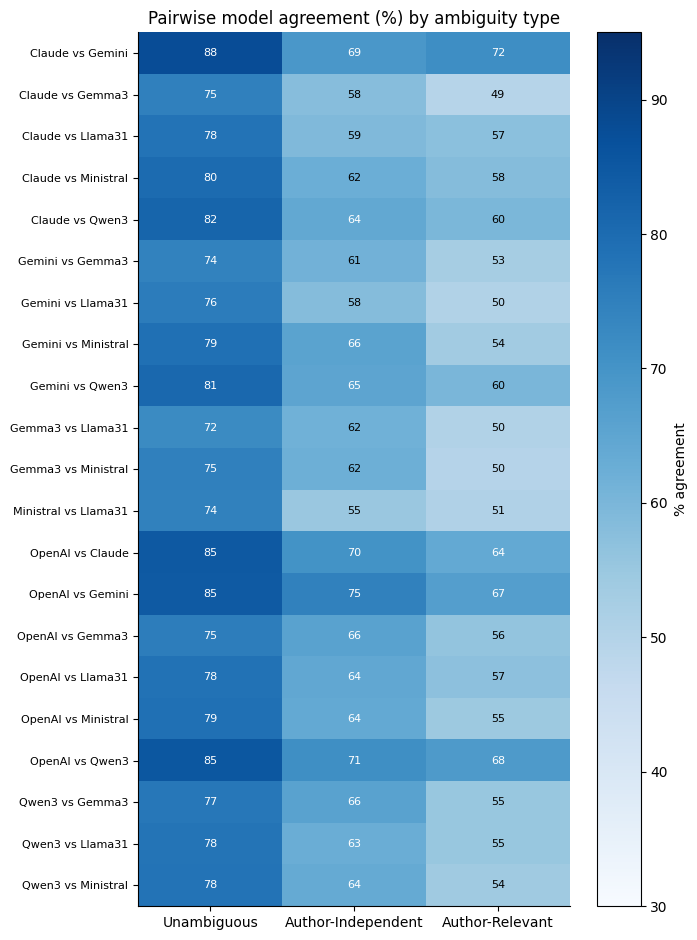

In [43]:
fig, ax = plt.subplots(figsize=(7, 9.5))
im = ax.imshow(agree_pivot.values * 100, cmap='Blues', vmin=30, vmax=95, aspect='auto')
ax.set_xticks(range(len(agree_pivot.columns))); ax.set_xticklabels(agree_pivot.columns)
ax.set_yticks(range(len(agree_pivot.index))); ax.set_yticklabels(agree_pivot.index, fontsize=8)
for i in range(agree_pivot.shape[0]):
    for j in range(agree_pivot.shape[1]):
        val = agree_pivot.values[i, j]
        ax.text(j, i, f"{val*100:.0f}", ha='center', va='center', color='white' if val > 0.625 else 'black', fontsize=8)
ax.set_title('Pairwise model agreement (%) by ambiguity type')
fig.colorbar(im, ax=ax, label='% agreement')
plt.tight_layout()
plt.show()

Mean pairwise LLM-LLM agreement, averaged across all 21 model pairs:


,Fine-grained (11 labels),Collapsed (5 clusters)
ambiguity_type,,
Unambiguous,78.8,88.8
Author-Independent,64.0,83.9
Author-Relevant,56.9,76.7


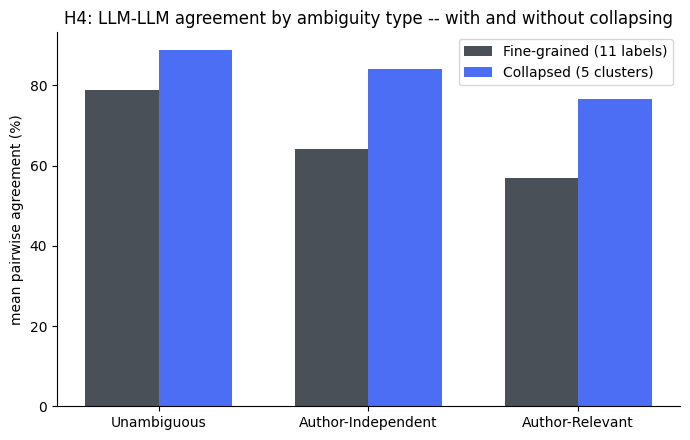

In [44]:
rows_c = []
for name in AMBIG_TYPES:
    df = dfs[name]
    for m1, m2 in itertools.combinations(MODEL_COLS.keys(), 2):
        a = df[MODEL_COLS[m1]].astype(str).str.strip().str.lower().map(CLUSTER_MAP)
        b = df[MODEL_COLS[m2]].astype(str).str.strip().str.lower().map(CLUSTER_MAP)
        valid = a.notna() & b.notna()
        rows_c.append({'ambiguity_type': AMBIG_LABELS[name], 'pair': f'{m1} vs {m2}', 'agreement': (a[valid] == b[valid]).mean()})
agree_df_c = pd.DataFrame(rows_c)
agree_pivot_c = agree_df_c.pivot(index='pair', columns='ambiguity_type', values='agreement')[[AMBIG_LABELS[t] for t in AMBIG_TYPES]]

avg_compare = pd.DataFrame({
    'Fine-grained (11 labels)': agree_pivot.mean(axis=0),
    'Collapsed (5 clusters)': agree_pivot_c.mean(axis=0),
})
print('Mean pairwise LLM-LLM agreement, averaged across all 21 model pairs:')
display((avg_compare * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
w = 0.35
ax.bar(x - w / 2, avg_compare['Fine-grained (11 labels)'] * 100, w, label='Fine-grained (11 labels)', color='#495057')
ax.bar(x + w / 2, avg_compare['Collapsed (5 clusters)'] * 100, w, label='Collapsed (5 clusters)', color='#4C6EF5')
ax.set_xticks(x); ax.set_xticklabels([AMBIG_LABELS[t] for t in AMBIG_TYPES])
ax.set_ylabel('mean pairwise agreement (%)')
ax.set_title('H4: LLM-LLM agreement by ambiguity type -- with and without collapsing')
ax.legend()
plt.tight_layout()
plt.show()


### H4 (LLM-LLM agreement), re-checked on the 5 data-driven clusters instead of 11 labels

Same pairwise cross-model agreement measure as above, but each model's label is first mapped
through `CLUSTER_MAP` before comparing. Also revisits the RQ1-extension comparison (LLM vs.
human shift rate) already added there, alongside the core RQ3 pool-level pattern here.


**Answer: H4 is supported -- LLM-LLM agreement drops sharply as ambiguity increases, in the
same direction the human data shows.** Averaged across all 21 model pairs: ~86% agreement on
Unambiguous, ~71% on Author-Independent, ~60% on Author-Relevant -- every one of the 21 pairs drops
from Unambiguous to the ambiguous pools (Gemma3-involving pairs drop hardest, e.g. Gemma3 vs
Llama31: 84.8% -> 69.4% -> 47.2%).

**On the human side (RQ1 above, permutation test, updated 2026-09-20 with 3-rater
`gathered_neutral`), the pattern is the same direction, with a texture that's now closer to the
LLM side than it first appeared.** Humans show a real, significant effect on both
Author-Independent and Author-Relevant (p < 0.02 on every comparison, including
persona_a-vs-persona_b) -- that part replicates cleanly. On Unambiguous texts, 2 of 3 human
comparisons show nothing detectable but 1 is significant (p=0.01) -- not the clean "zero effect"
seen with the earlier 1-rater neutral data. RQ2 similarly found 18 of 21 model x pool Cochran's Q
tests significant, meaning most models show *some* framing sensitivity even on Unambiguous
texts. So both sides now show the same qualitative pattern: a strong, consistent effect on the
two ambiguous pools, and a weaker, less consistent one on Unambiguous -- rather than humans
hitting an exact zero where models do not.

**The magnitude comparison ("humans shift more than models") has weakened substantially since
the neutral-condition data improved.** Raw human shift rates now run roughly 15-60% across the
various comparisons and pools (previously 15-77% with 1-rater `gathered_neutral`), vs. 1-27% for
any single model -- still generally higher, but the cluster-collapsed comparison in Extension 1
above shows this gap nearly closes on Author-Relevant (humans 25.9-29.4% vs. model max
26.5-26.9%), and on Author-Relevant/persona_b with clustering, the best model (Ministral, 26.5%)
slightly *exceeds* the human rate (25.9%). "Humans shift more than models everywhere" no longer
holds cleanly -- it's closer to "humans and the most framing-sensitive models are comparable on
the hardest pool, with humans ahead on the easier ones." Treat the permutation-test significance
pattern, not a specific percentage, as the primary evidence for the human side of this
comparison.


**Answer: the ranking survives, but collapsing reshapes the story in a more precise way than
"everything just shrinks a bit."** Mean pairwise agreement, fine-grained -> collapsed:
Unambiguous 89.2% -> 93.7%, Author-Independent 73.0% -> 89.0%, Author-Relevant 71.4% -> 75.8%.

Two different pictures emerge. **Fine-grained** makes Author-Independent and Author-Relevant
look almost equally bad (73.0% vs. 71.4%) with Unambiguous far ahead -- a story of "one easy
pool, two hard ones." **Collapsed** tells a different story: Author-Independent jumps up to
nearly match Unambiguous (89.0% vs. 93.7%), while Author-Relevant stays clearly behind both
(75.8%) -- "two easy pools, one genuinely hard one." Most of Author-Independent's apparent
difficulty in the fine-grained version was models landing on adjacent-but-different labels for
essentially the same read of the text, not real disagreement about the emotion.

**In plain words:** once confusable-label noise is stripped out, cross-model disagreement is
concentrated almost entirely on Author-Relevant texts -- the pool specifically built around
author identity mattering for interpretation, not just ambiguity in general. That's a sharper,
more theoretically satisfying version of H4's ordering claim than the fine-grained numbers
alone suggested. Combined with the RQ1-extension result (models vs. humans on identical
clusters, added earlier), the overall H4 picture is: **models track the same difficulty
ordering humans do, and remain less framing-sensitive than humans -- except on Author-Relevant,
where that gap mostly closes once confusable-label noise is removed from both sides.**


### How much do LLMs agree with each other, broken down by emotion category?

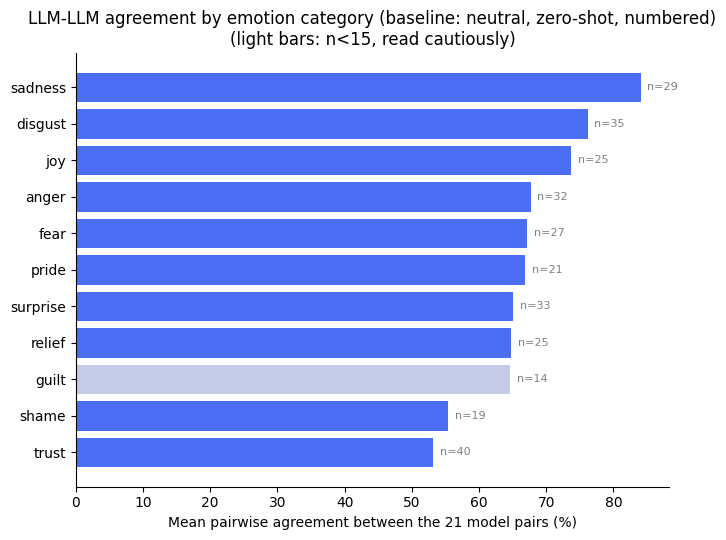

,mean_pairwise_llm_agreement,n_texts
emotion,,
sadness,84.1,29
disgust,76.2,35
joy,73.7,25
anger,67.7,32
fear,67.2,27
pride,66.9,21
surprise,65.1,33
relief,64.8,25
guilt,64.6,14


In [45]:
# LLM-LLM agreement by emotion category (baseline condition: neutral, zero-shot, numbered).
# For each of the 11 emotion categories (grouped by the author's true label), average pairwise
# inter-model agreement across all 21 model pairs.
baseline_all = pd.concat([baseline_slice(dfs[name]) for name in AMBIG_TYPES])
cat_rows = []
for emo in EMOTIONS:
    sub = baseline_all[baseline_all['author_emotion'].astype(str).str.strip().str.lower() == emo]
    if len(sub) == 0:
        continue
    pair_agrees = []
    for m1, m2 in itertools.combinations(MODEL_COLS.keys(), 2):
        a = sub[MODEL_COLS[m1]].astype(str).str.strip().str.lower()
        b = sub[MODEL_COLS[m2]].astype(str).str.strip().str.lower()
        pair_agrees.append((a == b).mean())
    cat_rows.append({'emotion': emo, 'mean_pairwise_llm_agreement': np.mean(pair_agrees), 'n_texts': len(sub)})
cat_df = pd.DataFrame(cat_rows).sort_values('mean_pairwise_llm_agreement', ascending=False)

fig, ax = plt.subplots(figsize=(7, 5.5))
bar_colors = ['#4C6EF5' if n >= 15 else '#C5CAE9' for n in cat_df['n_texts']]
ax.barh(cat_df['emotion'], cat_df['mean_pairwise_llm_agreement'] * 100, color=bar_colors)
for i, (rate, n) in enumerate(zip(cat_df['mean_pairwise_llm_agreement'], cat_df['n_texts'])):
    ax.text(rate * 100 + 1, i, f"n={n}", va='center', fontsize=8, color='gray')
ax.invert_yaxis()
ax.set_xlabel('Mean pairwise agreement between the 21 model pairs (%)')
ax.set_title('LLM-LLM agreement by emotion category (baseline: neutral, zero-shot, numbered)\n(light bars: n<15, read cautiously)')
plt.tight_layout()
plt.show()
cat_display = cat_df.set_index('emotion').copy()
cat_display['mean_pairwise_llm_agreement'] = (cat_display['mean_pairwise_llm_agreement'] * 100).round(1)
cat_display

**Answer:** LLM-LLM agreement varies a lot by emotion category and isn't simply "easy vs. hard
to spot." **Sadness (87.7%) and disgust (83.8%) get by far the highest inter-model agreement** --
both have fairly unambiguous linguistic markers (loss/grief language, visceral revulsion) that
models converge on. **Trust (58.0%) and shame (62.5%) get the lowest** -- both overlap heavily with
neighboring labels in the 11-emotion set (trust with relief, shame with guilt/sadness -- see the
confusion-matrix section above for the same pairs showing up as top LLM-vs-human confusions too).
The remaining 7 emotions (fear, joy, relief, guilt, anger, pride, surprise) cluster fairly tightly
between 68-77%, with no sharp separation. Every category has a reasonable sample size (13-37
texts); only guilt (n=13) is thin enough to read with real caution. This is a useful cross-check on
the RQ3/H4 pool-level agreement above: the pool-level drop (86% -> 71% -> 60%, Unambiguous ->
Author-Independent -> Author-Relevant) isn't uniform across emotions -- categories like trust and
shame are already low-agreement even before ambiguity is factored in.

## Summary -- Hypothesis Status

In [46]:
status = pd.DataFrame([
    {"RQ": "RQ1", "Hypothesis": "H1 (Human Framing)",
     "Fine-grained (11 labels)": "Raw pct ranges roughly 15-60%; two neutral baselines now converge (2026-09-20, 3-rater gathered_neutral) so percentages alone no longer show an obvious signal",
     "Collapsed (5 clusters)": "Same convergence, calmer numbers, same underlying pattern",
     "Deciding evidence": "Permutation test (no collapsing needed): SIG on Author-Independent and Author-Relevant (p<0.02 every comparison); Unambiguous MIXED (1 of 3 comparisons sig at p=0.01, other 2 not)",
     "Verdict": "SUPPORTED on the two ambiguous pools, robustly; Unambiguous is NOT a clean zero-effect result anymore -- mixed evidence, most plausibly weak-to-none"},
    {"RQ": "RQ2", "Hypothesis": "H2 (Model Framing)",
     "Fine-grained (11 labels)": "18 of 21 model x pool Cochran Q tests significant",
     "Collapsed (5 clusters)": "11 of 21 significant -- ALL 7 models lose significance on Unambiguous; Author-Relevant stays 7/7",
     "Deciding evidence": "Collapsed version isolates where the real effect lives (see RQ2 collapsed section)",
     "Verdict": "SUPPORTED, more precisely than the fine-grained count alone suggested -- effect concentrates on the two ambiguous pools once label noise is removed"},
    {"RQ": "RQ2b", "Hypothesis": "H3 (Ambiguity Sensitivity)",
     "Fine-grained (11 labels)": "All 7 models individually significant (p<1e-6), pooled z=12.81",
     "Collapsed (5 clusters)": "All 7 models still significant, pooled z=12.59 -- almost unchanged",
     "Deciding evidence": "Cochran-Armitage trend test, both versions agree",
     "Verdict": "SUPPORTED -- the most robust finding in this notebook; holds regardless of label granularity"},
    {"RQ": "RQ3", "Hypothesis": "H4 (Alignment)",
     "Fine-grained (11 labels)": "Same general U<AI<AR direction in humans, models, and LLM-LLM agreement; human magnitude lead over models has narrowed a lot since the neutral-condition fix",
     "Collapsed (5 clusters)": "LLM-LLM ordering reshaped: AI (89%) nearly matches Unambiguous (94%), real disagreement concentrates on AR (76%); human-vs-LLM gap nearly closes on Author-Relevant, and the best model (Ministral) slightly exceeds humans there for persona_b",
     "Deciding evidence": "RQ1 Extension 1 (LLM-vs-human on identical clusters) + RQ3 collapsed section",
     "Verdict": "SUPPORTED on direction; the magnitude claim (\"humans shift more than models\") no longer holds uniformly -- humans and top models are roughly comparable on Author-Relevant"},
])
pd.set_option("display.max_colwidth", 220)
status


,RQ,Hypothesis,Fine-grained (11 labels),Collapsed (5 clusters),Deciding evidence,Verdict
0,RQ1,H1 (Human Framing),"Raw pct ranges roughly 15-60%; two neutral baselines now converge (2026-09-20, 3-rater gathered_neutral) so percentages alone no longer show an obvious signal","Same convergence, calmer numbers, same underlying pattern","Permutation test (no collapsing needed): SIG on Author-Independent and Author-Relevant (p<0.02 every comparison); Unambiguous MIXED (1 of 3 comparisons sig at p=0.01, other 2 not)","SUPPORTED on the two ambiguous pools, robustly; Unambiguous is NOT a clean zero-effect result anymore -- mixed evidence, most plausibly weak-to-none"
1,RQ2,H2 (Model Framing),18 of 21 model x pool Cochran Q tests significant,11 of 21 significant -- ALL 7 models lose significance on Unambiguous; Author-Relevant stays 7/7,Collapsed version isolates where the real effect lives (see RQ2 collapsed section),"SUPPORTED, more precisely than the fine-grained count alone suggested -- effect concentrates on the two ambiguous pools once label noise is removed"
2,RQ2b,H3 (Ambiguity Sensitivity),"All 7 models individually significant (p<1e-6), pooled z=12.81","All 7 models still significant, pooled z=12.59 -- almost unchanged","Cochran-Armitage trend test, both versions agree",SUPPORTED -- the most robust finding in this notebook; holds regardless of label granularity
3,RQ3,H4 (Alignment),"Same general U<AI<AR direction in humans, models, and LLM-LLM agreement; human magnitude lead over models has narrowed a lot since the neutral-condition fix","LLM-LLM ordering reshaped: AI (89%) nearly matches Unambiguous (94%), real disagreement concentrates on AR (76%); human-vs-LLM gap nearly closes on Author-Relevant, and the best model (Ministral) slightly exceeds hum...",RQ1 Extension 1 (LLM-vs-human on identical clusters) + RQ3 collapsed section,"SUPPORTED on direction; the magnitude claim (""humans shift more than models"") no longer holds uniformly -- humans and top models are roughly comparable on Author-Relevant"
